# Two theories of sequence memory, side by side

### Raju et al. (2024) · *Space is a latent sequence* — clone-structured causal graphs
### Whittington et al. (2025) · *A tale of two algorithms* — activity slots vs. episodic weights

---

**The question this notebook answers:** these two papers look like they are about different
things — one is a theory of hippocampal place coding, the other a theory of prefrontal
working memory — but they are both theories of *how a sequence of experiences gets turned
into a reusable latent state*. Can they be put on the same footing, and what does each
one get right that the other does not?

**The claim that makes the comparison non-trivial.** The CSCG's inference procedure and
Whittington et al.'s RNN are not merely analogous; up to one nonlinearity they are the
same recurrent computation. Reading the CSCG update equations against `model.py` from the
`em-wm-slots` repository:

| CSCG (Raju et al.) | `AlternationN_Torch` (Whittington et al., `model.py`) |
|---|---|
| belief α_t over clones | hidden state `h` |
| `α⁻_t = α_{t-1} · T[a_t]` | `path_integrate`; with `transition_type='group'` the action embedding is literally reshaped into an h × h matrix |
| multiply by emission likelihood, renormalise | `gating_gen_inf` — the observation gated into the state |
| predict x_t from α⁻_t, *before* absorbing it | `preds.append(self.predict(pi_to_pred))` |
| clone = (observation, sequential context) | slot = (content, position) |
| EM / Baum–Welch on counts | backprop |
| Viterbi: `max_i( δ_{t-1,i} + log T[a_t]_{ij} ) + log E_{j,x_t}` | max-plus transition **plus additive input** — i.e. exactly the additively-gated, near-one-hot slot architecture |

So: **Bayesian filtering in a cloned HMM is a gated linear RNN over a belief state, and its
Viterbi limit is an additively-gated slot RNN.** Section 7 verifies this numerically, and
Section 8 exploits it to build a hybrid.

---

### What is actually run here

Everything is framed as a single shared interface — *next-observation prediction given an
action* — so that both model families run on both papers' tasks without modification.

| § | Experiment | What it decides |
|---|---|---|
| 1 | Shared task suite | Aliased 2-D room (Raju's turf); list recall & cue recall (Whittington's turf) |
| 2 | Head-to-head, spatial | Both solve it — but at wildly different sample cost |
| 3 | Head-to-head, memory | The slot RNN solves what the CSCG cannot |
| 4 | **Scaling law** | Exact causal-state count vs. slot count: factorial vs. linear |
| 5 | **Compositional generalisation** | Held-out item×position: slots transfer, clones cannot |
| 6 | Reciprocal critiques | Raju's place-field critique applied to the RNN; slot analysis applied to clones |
| 7 | **The unification** | CSCG ≡ RNN, verified to float precision; lossless transplant |
| 8 | **Hybrid** | EM as a fast structure learner, gradient descent as the refiner |
| 9 | Representational alignment | Ridge R², CKA, latent decodability |
| 10 | Discussion and limitations | What this does *not* show |

Sections 4, 5, 7 and 8 are the ones with real scientific content; the rest is scaffolding
and sanity-checking.

---

### Audit note (this revision)

Every result below was re-run from scratch in a clean environment. The CSCG numbers
reproduce bit-for-bit; the torch numbers move only in the third decimal across library
versions. Four things were corrected in the process, and each is flagged in place:

1. **§4 now has a closed form.** The causal-state count is not just a table — it is
   `S(N,O,D) = 2·Σ_{k=1..N} P(O,k) + (D+1)·P(O,N)`, verified three independent ways.
2. **§6b was misinterpreted.** Off-diagonal cross-decoding near 0 is *below* chance, and
   is forced by the without-replacement sampling design rather than being evidence about
   representational geometry. Oracle controls are added.
3. **§6a and §9 compared a smoothed belief against a causal filter.** A forward-only
   control is added; the effect turns out to be small.
4. **Place-field counting ignored the torus.** A periodic-boundary version is added.

The headline results (§4, §5, §7, §8) are unchanged by all of this.

In [ ]:
#@title Setup
import sys, subprocess, os, time, math
try:
    import torch
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch'], check=True)
    import torch

import numpy as np, matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white'})
torch.set_num_threads(os.cpu_count() or 2)

# QUICK=True keeps the whole notebook to roughly 10-15 min on a free Colab CPU.
# QUICK=False runs the fuller sweeps (roughly 45-70 min). No GPU is needed anywhere:
# these are tiny models and the CSCG is numpy-only.
QUICK = False
print('torch', torch.__version__, '| QUICK =', QUICK)

torch 2.11.0+cpu | QUICK = False


---
## 0. The four modules

The next four cells write the implementations to disk. They are deliberately written as
files rather than inline so that they can be diffed against the original sources.

* `cscg.py` — the clone-structured causal graph: action-conditioned cloned HMM, exact
  forward–backward, soft EM, Viterbi (hard) EM, Viterbi decoding.
* `tasks.py` — the shared task suite.
* `models.py` — the activity-slot RNN and the key–value episodic-memory model, mirroring
  `model.py` from `em-wm-slots`, plus the CSCG-as-RNN modules used in §6–8.
* `analysis.py` — capacity counting, place-field analysis, cross-decoding, alignment.
* `extras.py` — the controls added in this revision: causal (forward-only) beliefs,
  periodic-boundary field counting, and oracle codes for the cross-decoding diagnostic.

In [ ]:
%%writefile cscg.py
"""
Clone-structured causal graph (CSCG) / action-conditioned cloned HMM.

Re-implementation of the model in
  Raju, Guntupalli, Zhou, Wendelken, Lazaro-Gredilla & George,
  "Space is a latent sequence: A theory of the hippocampus",
  Sci. Adv. 10, eadm8470 (2024).

Key ideas kept faithful to the paper:
  * Latent states are "clones": each observation o owns a private block of C
    latent states, so the emission matrix is a fixed 0/1 block-indicator.
    Different clones of the same observation come to represent different
    *sequential contexts* -- this is what makes space emergent rather than assumed.
  * Transitions are action-conditioned, T[a] row-stochastic, learned by EM
    (Baum-Welch). All learned structure lives in *weights*.
  * Inference is exact message passing (forward-backward / Viterbi).

Because alpha_t is supported only on the block of clones belonging to x_t, all
messages are C-dimensional, not n_states-dimensional. We exploit that (and batch
sequences by the (x_{t-1}, x_t, a_t) triple) so EM is fast enough for Colab.

Time convention (shared with models.py):
    a[t] is the action taken between t-1 and t; the transition into time t is T[a[t]].
    a[0] is unused.
"""

import numpy as np

EPS = 1e-30


class CSCG:
    """Action-conditioned cloned HMM, uniform number of clones per observation."""

    def __init__(self, n_obs, n_clones, n_act, seed=0, pseudocount=1e-3, init_sharpness=4.0):
        """init_sharpness > 1 gives a sparse (peaky) random T. This matters a lot:
        a near-uniform init leaves all clones exchangeable and Baum-Welch sits in
        the symmetric saddle, badly under-fitting memorisation tasks."""
        self.rng = np.random.default_rng(seed)
        self.n_obs = int(n_obs)
        self.C = int(n_clones)
        self.n_act = int(n_act)
        self.n_states = self.n_obs * self.C
        self.pseudocount = pseudocount
        T = self.rng.random((self.n_act, self.n_states, self.n_states)) ** init_sharpness + 1e-6
        self.T = T / T.sum(-1, keepdims=True)
        self.pi = np.full(self.C, 1.0 / self.C)     # prior within the first block

    # ---------------------------------------------------------------- utilities
    def _blk(self, o):
        return o * self.C, (o + 1) * self.C

    @staticmethod
    def _groups(keys):
        """Index groups of rows of `keys` that are identical (keys: (B,k) ints)."""
        if keys.ndim == 1:
            keys = keys[:, None]
        mult = np.array([keys[:, i].max() + 1 for i in range(keys.shape[1])])
        flat = np.zeros(keys.shape[0], dtype=np.int64)
        for i in range(keys.shape[1]):
            flat = flat * mult[i] + keys[:, i]
        _, inv = np.unique(flat, return_inverse=True)
        order = np.argsort(inv, kind='stable')
        bounds = np.searchsorted(inv[order], np.arange(inv.max() + 2))
        return [order[bounds[i]:bounds[i + 1]] for i in range(len(bounds) - 1)
                if bounds[i + 1] > bounds[i]]

    # ---------------------------------------------------------------- inference
    def forward(self, x, a, want_pred=False):
        """Scaled forward pass restricted to clone blocks.

        alpha : (B,T,C) filtered belief inside the block of x_t
        pred  : (B,T,n_obs) one-step-ahead predictive p(x_t | x_<t, a_<=t)
        ll    : (B,) log-likelihood
        """
        B, Tn = x.shape
        C = self.C
        alpha = np.zeros((B, Tn, C))
        pred = np.zeros((B, Tn, self.n_obs)) if want_pred else None
        ll = np.zeros(B)

        alpha[:, 0] = self.pi
        if want_pred:
            pred[:, 0] = 1.0 / self.n_obs

        for t in range(1, Tn):
            prev_o, cur_o, act = x[:, t - 1], x[:, t], a[:, t]
            if want_pred:
                for idx in self._groups(np.stack([prev_o, act], 1)):
                    i0, i1 = self._blk(prev_o[idx[0]])
                    full = alpha[idx, t - 1] @ self.T[act[idx[0]], i0:i1, :]
                    full = full.reshape(len(idx), self.n_obs, C).sum(-1)
                    pred[idx, t] = full / (full.sum(-1, keepdims=True) + EPS)
            for idx in self._groups(np.stack([prev_o, cur_o, act], 1)):
                i0, i1 = self._blk(prev_o[idx[0]])
                j0, j1 = self._blk(cur_o[idx[0]])
                m = alpha[idx, t - 1] @ self.T[act[idx[0]], i0:i1, j0:j1]
                s = m.sum(-1) + EPS
                ll[idx] += np.log(s)
                alpha[idx, t] = m / s[:, None]
        return (alpha, pred, ll) if want_pred else (alpha, ll)

    def backward(self, x, a):
        B, Tn = x.shape
        beta = np.zeros((B, Tn, self.C))
        beta[:, -1] = 1.0
        for t in range(Tn - 2, -1, -1):
            cur_o, nxt_o, act = x[:, t], x[:, t + 1], a[:, t + 1]
            for idx in self._groups(np.stack([cur_o, nxt_o, act], 1)):
                i0, i1 = self._blk(cur_o[idx[0]])
                j0, j1 = self._blk(nxt_o[idx[0]])
                out = beta[idx, t + 1] @ self.T[act[idx[0]], i0:i1, j0:j1].T
                beta[idx, t] = out / (out.sum(-1, keepdims=True) + EPS)
        return beta

    def posterior(self, x, a, dense=False):
        """gamma_t = p(z_t | x_{1:T}, a): the 'clone activation'."""
        alpha, _ = self.forward(x, a)
        beta = self.backward(x, a)
        g = alpha * beta
        g = g / (g.sum(-1, keepdims=True) + EPS)
        if not dense:
            return g
        B, Tn = x.shape
        G = np.zeros((B, Tn, self.n_states))
        base = x * self.C
        for c in range(self.C):
            np.put_along_axis(G, (base + c)[..., None], g[..., c:c + 1], axis=-1)
        return G

    # ---------------------------------------------------------------- prediction
    def predict_obs(self, x, a):
        _, pred, _ = self.forward(x, a, want_pred=True)
        return pred

    def accuracy(self, x, a, mask):
        p = self.predict_obs(x, a)
        return float(((p.argmax(-1) == x) * mask).sum() / max(mask.sum(), 1))

    def bits_per_step(self, x, a, mask=None):
        p = self.predict_obs(x, a)
        lp = np.log2(np.take_along_axis(p, x[..., None], -1)[..., 0] + EPS)
        if mask is None:
            return float(-lp.mean())
        return float(-(lp * mask).sum() / max(mask.sum(), 1))

    # ---------------------------------------------------------------- learning
    def em_step(self, x, a):
        """One Baum-Welch iteration. Returns mean log-likelihood per step."""
        B, Tn = x.shape
        alpha, ll = self.forward(x, a)
        beta = self.backward(x, a)
        counts = np.zeros_like(self.T)
        for t in range(1, Tn):
            prev_o, cur_o, act = x[:, t - 1], x[:, t], a[:, t]
            for idx in self._groups(np.stack([prev_o, cur_o, act], 1)):
                i0, i1 = self._blk(prev_o[idx[0]])
                j0, j1 = self._blk(cur_o[idx[0]])
                A = act[idx[0]]
                xi = np.einsum('bi,ij,bj->bij', alpha[idx, t - 1],
                               self.T[A, i0:i1, j0:j1], beta[idx, t])
                xi /= (xi.sum((1, 2), keepdims=True) + EPS)
                counts[A, i0:i1, j0:j1] += xi.sum(0)
        counts += self.pseudocount
        self.T = counts / counts.sum(-1, keepdims=True)
        return float(ll.mean() / Tn)

    def fit(self, x, a, n_iter=40, verbose=False, tol=1e-5):
        hist, prev = [], -np.inf
        for it in range(n_iter):
            l = self.em_step(x, a)
            hist.append(l)
            if verbose and (it % 10 == 0 or it == n_iter - 1):
                print(f'    EM {it:3d}  loglik/step = {l:.4f}')
            if abs(l - prev) < tol:
                break
            prev = l
        return hist

    def hard_em_step(self, x, a):
        """Viterbi ('hard') EM: count transitions along the MAP path.
        Used by Dedieu et al. / Raju et al. as a refinement after soft EM --
        it sharpens the learned graph and escapes some soft-EM plateaus."""
        path, ll = self.viterbi(x, a)
        counts = np.zeros_like(self.T)
        B, Tn = x.shape
        for t in range(1, Tn):
            np.add.at(counts, (a[:, t], path[:, t - 1], path[:, t]), 1.0)
        counts += self.pseudocount
        self.T = counts / counts.sum(-1, keepdims=True)
        return float(ll.mean() / Tn)

    def refine(self, x, a, n_iter=20):
        return [self.hard_em_step(x, a) for _ in range(n_iter)]

    @staticmethod
    def fit_best(n_obs, n_clones, n_act, x, a, n_iter=100, n_restarts=3,
                 seed0=0, refine_iter=0, score_x=None, score_a=None, **kw):
        """EM is non-convex; run a few restarts and keep the best likelihood.
        This is the fair way to give the CSCG its best shot on memorisation tasks."""
        sx = x if score_x is None else score_x
        sa = a if score_a is None else score_a
        best, best_ll = None, -np.inf
        for r in range(n_restarts):
            m = CSCG(n_obs, n_clones, n_act, seed=seed0 + r, **kw)
            m.fit(x, a, n_iter=n_iter)
            if refine_iter:
                m.refine(x, a, n_iter=refine_iter)
            _, ll = m.forward(sx, sa)
            ll = float(ll.mean() / sx.shape[1])
            if ll > best_ll:
                best, best_ll = m, ll
        return best, best_ll

    # ---------------------------------------------------------------- decoding
    def viterbi(self, x, a):
        """MAP clone path (B,T) as global state ids.

        The recursion is a max-plus ('tropical') matmul plus an additive emission
        term -- i.e. an additively-gated linear RNN in log space. See Section 7.
        """
        B, Tn = x.shape
        logT = np.log(self.T + EPS)
        delta = np.log(self.pi + EPS)[None, :].repeat(B, 0)
        psi = np.zeros((B, Tn, self.C), dtype=np.int32)
        for t in range(1, Tn):
            prev_o, cur_o, act = x[:, t - 1], x[:, t], a[:, t]
            new = np.zeros((B, self.C))
            for idx in self._groups(np.stack([prev_o, cur_o, act], 1)):
                i0, i1 = self._blk(prev_o[idx[0]])
                j0, j1 = self._blk(cur_o[idx[0]])
                sc = delta[idx][:, :, None] + logT[act[idx[0]], i0:i1, j0:j1][None]
                psi[idx, t] = sc.argmax(1)
                new[idx] = sc.max(1)
            delta = new
        path = np.zeros((B, Tn), dtype=np.int32)
        path[:, -1] = delta.argmax(-1)
        for t in range(Tn - 2, -1, -1):
            path[:, t] = psi[np.arange(B), t + 1, path[:, t + 1]]
        return path + x * self.C, delta.max(-1)

    # ---------------------------------------------------------------- bookkeeping
    def n_used_states(self, x, a, thresh=0.02):
        g = self.posterior(x, a, dense=True).reshape(-1, self.n_states).mean(0)
        return int((g > thresh * g.max()).sum())

    @property
    def n_params(self):
        return int(self.n_act * self.n_states * (self.n_states - 1))


# --------------------------------------------------------------------------------
# Dense-emission variant for the schema-transfer experiment (Raju et al.: keep the
# learned transition graph, relearn only the emission matrix in a new environment).
# --------------------------------------------------------------------------------
class DenseHMM:
    def __init__(self, T, n_obs, seed=0, pseudocount=1e-2):
        self.T = T.copy()
        self.n_act, self.n_states, _ = T.shape
        self.n_obs = n_obs
        rng = np.random.default_rng(seed)
        E = rng.random((self.n_states, n_obs)) + 1.0
        self.E = E / E.sum(-1, keepdims=True)
        self.pi = np.full(self.n_states, 1.0 / self.n_states)
        self.pseudocount = pseudocount

    def _fb(self, x, a):
        B, Tn = x.shape
        lik = self.E[:, x].transpose(1, 2, 0)
        alpha = np.zeros((B, Tn, self.n_states)); prior = np.zeros_like(alpha)
        ll = np.zeros(B)
        prior[:, 0] = self.pi
        m = prior[:, 0] * lik[:, 0]; s = m.sum(-1) + EPS
        ll += np.log(s); alpha[:, 0] = m / s[:, None]
        for t in range(1, Tn):
            p = np.zeros((B, self.n_states)); at = a[:, t]
            for act in np.unique(at):
                i = np.where(at == act)[0]
                p[i] = alpha[i, t - 1] @ self.T[act]
            prior[:, t] = p
            m = p * lik[:, t]; s = m.sum(-1) + EPS
            ll += np.log(s); alpha[:, t] = m / s[:, None]
        beta = np.zeros_like(alpha); beta[:, -1] = 1.0
        for t in range(Tn - 2, -1, -1):
            v = beta[:, t + 1] * lik[:, t + 1]
            o = np.zeros((B, self.n_states)); at = a[:, t + 1]
            for act in np.unique(at):
                i = np.where(at == act)[0]
                o[i] = v[i] @ self.T[act].T
            beta[:, t] = o / (o.sum(-1, keepdims=True) + EPS)
        return alpha, beta, prior, ll

    def fit_emission(self, x, a, n_iter=30):
        hist = []
        for _ in range(n_iter):
            alpha, beta, _, ll = self._fb(x, a)
            g = alpha * beta; g = g / (g.sum(-1, keepdims=True) + EPS)
            Ec = np.zeros_like(self.E)
            for o in range(self.n_obs):
                m = (x == o)
                if m.any():
                    Ec[:, o] = g[m].sum(0)
            Ec += self.pseudocount
            self.E = Ec / Ec.sum(-1, keepdims=True)
            hist.append(float(ll.mean() / x.shape[1]))
        return hist

    def accuracy(self, x, a, mask):
        _, _, prior, _ = self._fb(x, a)
        p = prior @ self.E
        p = p / (p.sum(-1, keepdims=True) + EPS)
        return float(((p.argmax(-1) == x) * mask).sum() / max(mask.sum(), 1))

Overwriting cscg.py


In [ ]:
%%writefile tasks.py
"""
A common task suite so that the CSCG (Raju et al. 2024) and the activity-slot
RNN / episodic-memory models (Whittington et al. 2025) can be run head-to-head.

Every task emits the *same* interface, framed as next-observation prediction:

    obs    (B, T) int   observation at each step
    act    (B, T) int   action taken between t-1 and t (act[:,0] unused)
    mask   (B, T) bool  steps that count towards the score
    latent (B, T) int   ground-truth latent state (for analysis only)

At step t a model must output p(obs_t) using only obs_{<t} and act_{<=t}.
This is exactly the CSCG one-step-ahead predictive, and exactly the
`path_integrate -> predict` path of Whittington et al.'s model.py (which
predicts the current observation from the path-integrated state, *before*
that observation is gated into the hidden state).

Two families:
  * AliasedRoom   -- CSCG's home turf: aliased egocentric observations, actions,
                     latent 2D map to be discovered.
  * ListRecall    -- Whittington's home turf: hold N items in order, then
    CueRecall        reproduce / report the cued one. No spatial structure,
                     but strong content x position binding.
"""

import numpy as np


class Task:
    name = 'task'
    n_obs = 0
    n_act = 1
    seq_len = 0

    def sample(self, batch_size, rng):
        raise NotImplementedError

    def batch(self, batch_size, seed=0):
        rng = np.random.default_rng(seed)
        return self.sample(batch_size, rng)


# ----------------------------------------------------------------------------------
class AliasedRoom(Task):
    """Random walk in a HxW room with aliased observations (Raju et al., Fig. 1D).

    A single fixed environment: colours are drawn once and shared across all walks,
    so there are far fewer observations than locations and the agent must use
    *sequential context* to disambiguate. Actions are the 4 cardinal moves.
    """
    name = 'aliased_room'

    def __init__(self, H=6, W=6, n_colors=5, seq_len=200, torus=True, seed=0,
                 uniform_interior=False, burn_in=10):
        self.H, self.W, self.n_colors, self.torus = H, W, n_colors, torus
        self.seq_len = seq_len
        self.burn_in = burn_in
        self.n_obs = n_colors
        self.n_act = 4                      # 0:up 1:down 2:left 3:right
        r = np.random.default_rng(seed)
        if uniform_interior:
            # like Raju Fig 1D(i): uniform interior, informative border
            m = np.zeros((H, W), dtype=int)
            m[:] = 0
            m[0, :] = 1; m[-1, :] = 2; m[:, 0] = 3; m[:, -1] = 4
            self.colors = m % n_colors
        else:
            self.colors = r.integers(0, n_colors, size=(H, W))
        self.n_latent = H * W

    def _step(self, y, x, a):
        dy = np.where(a == 0, -1, np.where(a == 1, 1, 0))
        dx = np.where(a == 2, -1, np.where(a == 3, 1, 0))
        ny, nx = y + dy, x + dx
        if self.torus:
            return ny % self.H, nx % self.W
        ny = np.clip(ny, 0, self.H - 1); nx = np.clip(nx, 0, self.W - 1)
        return ny, nx

    def sample(self, B, rng):
        T = self.seq_len
        y = rng.integers(0, self.H, B); x = rng.integers(0, self.W, B)
        obs = np.zeros((B, T), dtype=np.int64)
        act = np.zeros((B, T), dtype=np.int64)
        lat = np.zeros((B, T), dtype=np.int64)
        obs[:, 0] = self.colors[y, x]; lat[:, 0] = y * self.W + x
        for t in range(1, T):
            a = rng.integers(0, self.n_act, B)
            y, x = self._step(y, x, a)
            act[:, t] = a
            obs[:, t] = self.colors[y, x]
            lat[:, t] = y * self.W + x
        mask = np.zeros((B, T), dtype=bool); mask[:, self.burn_in:] = True
        return dict(obs=obs, act=act, mask=mask, latent=lat)


# ----------------------------------------------------------------------------------
class ListRecall(Task):
    """Serial recall (the canonical WM-slot task).

    tokens:  0..O-1 items | O = DELAY | O+1 = GO
    trial :  [i_1 .. i_N] [DELAY x D] [GO] [i_1 .. i_N]
    scored:  the N recall steps.

    A model must hold N items *in order* across the delay. Under Whittington's
    theory this is solved by N activity slots; under a cloned-HMM it requires a
    distinct latent state for every distinct list prefix -- the combinatorial
    blow-up that Section 4 measures.
    """
    name = 'list_recall'

    def __init__(self, n_items=3, vocab=5, delay=3, replace=False,
                 forbid=(), require=()):
        """forbid / require: sets of (item, position) pairs.

        Used for the compositional-generalisation test. Train with
        forbid={(0,0)} -- item 0 is never seen in position 0 -- then test with
        require={(0,0)}. A factorised slot code should transfer; a code that
        enumerates joint (item, position) contexts, as clones do, cannot.
        """
        self.N, self.O, self.D = n_items, vocab, delay
        self.replace = replace
        self.forbid, self.require = set(forbid), set(require)
        self.DELAY, self.GO = vocab, vocab + 1
        self.n_obs = vocab + 2
        self.n_act = 3               # 0:encode 1:wait 2:recall  (an explicit phase signal)
        self.seq_len = n_items + delay + 1 + n_items
        self.n_latent = self.seq_len

    def _draw_items(self, B, rng):
        out = []
        while len(out) < B:
            if self.replace:
                cand = rng.integers(0, self.O, size=(4 * B, self.N))
            else:
                cand = np.stack([rng.permutation(self.O)[:self.N] for _ in range(4 * B)])
            ok = np.ones(len(cand), dtype=bool)
            for (it, pos) in self.forbid:
                ok &= (cand[:, pos] != it)
            for (it, pos) in self.require:
                ok &= (cand[:, pos] == it)
            out.extend(cand[ok])
        return np.array(out[:B])

    def sample(self, B, rng):
        N, D, T = self.N, self.D, self.seq_len
        items = self._draw_items(B, rng)
        obs = np.zeros((B, T), dtype=np.int64)
        obs[:, :N] = items
        obs[:, N:N + D] = self.DELAY
        obs[:, N + D] = self.GO
        obs[:, N + D + 1:] = items
        act = np.zeros((B, T), dtype=np.int64)
        act[:, :N] = 0
        act[:, N:N + D + 1] = 1
        act[:, N + D + 1:] = 2
        mask = np.zeros((B, T), dtype=bool); mask[:, N + D + 1:] = True
        lat = np.tile(np.arange(T), (B, 1))
        return dict(obs=obs, act=act, mask=mask, latent=lat, items=items)


class CueRecall(Task):
    """Cue-dependent recall, after Panichello & Buschman (2021).

    tokens: 0..O-1 items | O..O+N-1 = cues | O+N = DELAY
    trial : [i_1 .. i_N] [DELAY x D] [CUE_k] [i_k]
    scored: the final step (report the cued item).

    Whittington et al. model this as: load items into slots, then use the cue as a
    *velocity* signal that shifts the correct item into the read-out slot.
    """
    name = 'cue_recall'

    def __init__(self, n_items=2, vocab=6, delay=2, replace=False):
        self.N, self.O, self.D = n_items, vocab, delay
        self.replace = replace
        self.DELAY = vocab + n_items
        self.n_obs = vocab + n_items + 1
        self.n_act = 2 + n_items      # 0:encode 1:wait 2+k:cue k
        self.seq_len = n_items + delay + 1 + 1
        self.n_latent = self.seq_len

    def sample(self, B, rng):
        N, D, T = self.N, self.D, self.seq_len
        if self.replace:
            items = rng.integers(0, self.O, size=(B, N))
        else:
            items = np.stack([rng.permutation(self.O)[:N] for _ in range(B)])
        cue = rng.integers(0, N, size=B)
        obs = np.zeros((B, T), dtype=np.int64)
        obs[:, :N] = items
        obs[:, N:N + D] = self.DELAY
        obs[:, N + D] = self.O + cue
        obs[:, -1] = items[np.arange(B), cue]
        act = np.zeros((B, T), dtype=np.int64)
        act[:, :N] = 0
        act[:, N:N + D] = 1
        act[:, N + D] = 1
        act[:, -1] = 2 + cue          # the cue acts as the transition/velocity signal
        mask = np.zeros((B, T), dtype=bool); mask[:, -1] = True
        lat = np.tile(np.arange(T), (B, 1))
        return dict(obs=obs, act=act, mask=mask, latent=lat, items=items, cue=cue)


def chance_level(task):
    """Accuracy of the best observation-marginal predictor on scored steps."""
    d = task.batch(512, seed=999)
    o, m = d['obs'], d['mask']
    vals, cts = np.unique(o[m], return_counts=True)
    return float(cts.max() / cts.sum())

Overwriting tasks.py


In [ ]:
%%writefile models.py
"""
Activity-slot RNN and episodic-memory (key-value) models.

Faithful-but-compact re-implementations of the two model families in
  Whittington, Dorrell, Ganguli, Behrens & El-Gaby,
  "A tale of two algorithms: Structured slots explain prefrontal sequence memory
   and are unified with hippocampal cognitive maps", Neuron (2025).
  Reference code: github.com/.../em-wm-slots  (model.py)

Correspondence to the original `AlternationN_Torch` in model.py:

    inputs_to_hidden      -> self.embed_o / self.embed_a      (input embeddings)
    path_integrate        -> self.path_integrate              ('rnn_add' | 'group')
    rnn_act               -> relu + threshold_torch           (same soft threshold)
    norm_pi_to_pred       -> LayerNorm(elementwise_affine=False)
    gating_gen_inf        -> sigmoid gate between path-integrated state and input
    predict_t             -> linear readout to observations
    add_memory / retrieve -> EMModel below (key-value store + softmax attention,
                             with the same 1 + log(n_mem - 1) inverse temperature)

Time convention matches cscg.py: a[t] is the action taken between t-1 and t.
At step t the model path-integrates with a[t], predicts obs_t, then gates obs_t in.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

EPS = 1e-8


def threshold_torch(x, thresh=10.0, slope=0.05):
    """Soft saturating threshold, copied from model_utils.threshold_torch."""
    between = torch.clamp(x, min=-thresh, max=thresh)
    above = torch.clamp(x - thresh, min=0)
    below = torch.clamp(x + thresh, max=0)
    return between + slope * (above + below)


# ==================================================================== slot RNN
class SlotRNN(nn.Module):
    """Whittington et al.'s working-memory model: memories held in *activity*.

    transition : 'rnn_add'  pi = W h + Wv(a)          (additive action input)
                 'group'    pi = M(a) h               (action-conditioned matrix;
                                                       this is the 'group' transition
                                                       of model.py and the closest
                                                       analogue of the CSCG's T[a])
    gate       : 'add'      h = s*pi + (1-s)*inp      (as in model.py)
                 'mult'     h = pi * sigmoid(inp)     (multiplicative; the exact
                                                       analogue of an HMM emission
                                                       likelihood multiply)
    """

    def __init__(self, n_obs, n_act, h_size=128, transition='group', gate='add',
                 hidden_act='relu', add_identity=True, norm_pi=True,
                 d_mixed=16, thresh=10.0, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.n_obs, self.n_act, self.h = n_obs, n_act, h_size
        self.transition_type, self.gate_type = transition, gate
        self.add_identity = add_identity and transition != 'group'
        self.hidden_act = hidden_act
        self.thresh = thresh

        self.embed_o = nn.Embedding(n_obs, h_size)
        self.hidden_init = nn.Parameter(torch.zeros(1, h_size))

        if transition == 'rnn_add':
            self.transition = nn.Linear(h_size, h_size, bias=True)
            nn.init.trunc_normal_(self.transition.weight, std=1e-3)
            nn.init.zeros_(self.transition.bias)
            self.embed_a = nn.Embedding(n_act, h_size)
        elif transition == 'group':
            # action -> full h x h transition matrix (model.py: get_transition_vec)
            self.get_transition_vec = nn.Sequential(
                nn.Embedding(n_act, d_mixed), nn.SiLU(),
                nn.Linear(d_mixed, h_size * h_size))
            nn.init.trunc_normal_(self.get_transition_vec[2].weight, std=1e-3)
            nn.init.zeros_(self.get_transition_vec[2].bias)
        else:
            raise ValueError(transition)

        self.norm_pi = nn.LayerNorm(h_size, elementwise_affine=False) if norm_pi else nn.Identity()
        self.gate_net = nn.Sequential(nn.Linear(2 * h_size, h_size), nn.Sigmoid())
        self.readout = nn.Linear(h_size, n_obs)
        nn.init.normal_(self.embed_o.weight, std=0.06)
        nn.init.normal_(self.readout.weight, std=0.1)

    # -------------------------------------------------------------- components
    def act(self, x):
        if self.hidden_act == 'relu':
            x = F.relu(x)
        elif self.hidden_act == 'tanh':
            x = torch.tanh(x)
        return threshold_torch(x, self.thresh)

    def path_integrate(self, h, a):
        if self.transition_type == 'rnn_add':
            pi = self.transition(h) + self.embed_a(a)
        else:
            M = self.get_transition_vec(a).reshape(-1, self.h, self.h)
            pi = torch.bmm(M, h[..., None]).squeeze(-1)
        if self.add_identity:
            pi = pi + h
        return pi

    def gate(self, pi, inp):
        if self.gate_type == 'add':
            s = self.gate_net(torch.cat([pi, inp], -1))
            return s * pi + (1 - s) * inp
        return pi * torch.sigmoid(inp)

    # -------------------------------------------------------------- forward
    def forward(self, obs, act, return_hidden=False):
        """obs, act: (B,T) long. Returns logits (B,T,n_obs)."""
        B, T = obs.shape
        inp = self.embed_o(obs)                       # (B,T,h)
        h = self.act(self.hidden_init.expand(B, -1))
        logits, hs, pis = [], [], []
        for t in range(T):
            pi = self.path_integrate(h, act[:, t]) if t > 0 else h
            pi_pred = self.norm_pi(self.act(pi))
            logits.append(self.readout(pi_pred))      # predict obs_t BEFORE seeing it
            h = self.act(self.gate(pi, inp[:, t]))
            if return_hidden:
                hs.append(h); pis.append(pi_pred)
        out = torch.stack(logits, 1)
        if return_hidden:
            return out, torch.stack(hs, 1), torch.stack(pis, 1)
        return out


# ==================================================================== EM model
class EMModel(nn.Module):
    """Whittington et al.'s episodic-memory model: memories held in *weights*
    (a key-value / Hopfield store written online), read out by attention.

    Mirrors model.py's `add_memory` / `retrieve_memory`, including the
    beta = 1 + log(max(n_mem,2) - 1) inverse-temperature schedule.
    """

    def __init__(self, n_obs, n_act, h_size=128, key_size=64, transition='group',
                 d_mixed=16, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.backbone = SlotRNN(n_obs, n_act, h_size, transition=transition,
                                gate='add', d_mixed=d_mixed, seed=seed)
        self.h = h_size
        self.wq_k = nn.Linear(h_size, key_size, bias=False)
        self.wv = nn.Linear(h_size, h_size, bias=False)
        self.key_size = key_size
        self.norm_mem = nn.LayerNorm(h_size, elementwise_affine=False)
        self.readout = nn.Linear(h_size, n_obs)

    def forward(self, obs, act, return_hidden=False):
        B, T = obs.shape
        bb = self.backbone
        inp = bb.embed_o(obs)
        h = bb.act(bb.hidden_init.expand(B, -1))
        keys = torch.zeros(B, 0, self.key_size, device=obs.device)
        vals = torch.zeros(B, 0, self.h, device=obs.device)
        logits, hs, attns = [], [], []
        for t in range(T):
            pi = bb.path_integrate(h, act[:, t]) if t > 0 else h
            pi_pred = bb.norm_pi(bb.act(pi))
            if t > 0:
                q = self.wq_k(pi_pred)
                ip = torch.einsum('bmk,bk->bm', keys, q) / self.key_size ** 0.5
                beta = 1.0 + np.log(max(t, 2) - 1 + EPS)
                attn = torch.softmax(ip * beta, dim=1)
                mem = torch.einsum('bm,bmh->bh', attn, vals)
                attns.append(attn)
            else:
                mem = torch.zeros(B, self.h, device=obs.device)
            logits.append(self.readout(self.norm_mem(mem)))
            h = bb.act(bb.gate(pi, inp[:, t]))
            # write: key from current state, value corrected by what is already stored
            keys = torch.cat([keys, self.wq_k(h)[:, None]], 1)
            vals = torch.cat([vals, (self.wv(h) - mem)[:, None]], 1)
            if return_hidden:
                hs.append(h)
        out = torch.stack(logits, 1)
        if return_hidden:
            return out, torch.stack(hs, 1), attns
        return out


# ==================================================================== training
def train_model(model, task, steps=2000, batch=64, lr=8e-4, device='cpu',
                seed=0, log_every=None, eval_batch=256):
    """Cross-entropy on masked steps, Adam+amsgrad (as in run_model.py)."""
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, amsgrad=True)
    rng = np.random.default_rng(seed)
    ev = task.batch(eval_batch, seed=10_000 + seed)
    ev = {k: torch.as_tensor(v).to(device) for k, v in ev.items() if k in ('obs', 'act', 'mask')}
    hist = []
    for s in range(steps):
        d = task.sample(batch, rng)
        o = torch.as_tensor(d['obs']).to(device)
        a = torch.as_tensor(d['act']).to(device)
        m = torch.as_tensor(d['mask']).to(device)
        logits = model(o, a)
        loss = (F.cross_entropy(logits.reshape(-1, task.n_obs), o.reshape(-1),
                                reduction='none').reshape(o.shape) * m).sum() / m.sum()
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()
        if log_every and (s % log_every == 0 or s == steps - 1):
            acc = evaluate(model, ev)
            hist.append((s, float(loss.item()), acc))
            print(f'    step {s:5d}  loss {loss.item():.4f}  acc {acc:.3f}', flush=True)
    return hist, evaluate(model, ev)


@torch.no_grad()
def evaluate(model, ev):
    logits = model(ev['obs'], ev['act'])
    correct = (logits.argmax(-1) == ev['obs']).float()
    return float((correct * ev['mask']).sum() / ev['mask'].sum())


@torch.no_grad()
def hidden_states(model, obs, act, device='cpu'):
    o = torch.as_tensor(obs).to(device); a = torch.as_tensor(act).to(device)
    out = model(o, a, return_hidden=True)
    return [x.cpu().numpy() if torch.is_tensor(x) else x for x in out]


# ==================================================================== CSCG as RNN
class BeliefRNN(nn.Module):
    """The CSCG forward pass written as a recurrent network.

        pi_t = h_{t-1} @ T[a_t]            <- an action-conditioned linear map,
                                              i.e. exactly a 'group' transition
        p(x_t) = pi_t @ E                  <- linear readout through the clone map
        h_t   = normalise(pi_t * E[:,x_t]) <- *multiplicative* input gating

    So Bayesian filtering in a cloned HMM IS a gated linear RNN whose hidden state
    is a belief over clones. Section 7 of the notebook checks this numerically
    against the numpy CSCG.
    """

    def __init__(self, cscg_model, learnable=False):
        super().__init__()
        T = torch.tensor(cscg_model.T, dtype=torch.float32)
        self.n_states, self.C, self.n_obs = cscg_model.n_states, cscg_model.C, cscg_model.n_obs
        E = torch.zeros(self.n_states, self.n_obs)
        for o in range(self.n_obs):
            E[o * self.C:(o + 1) * self.C, o] = 1.0
        # T is parameterised in logit space so that gradient descent keeps it
        # row-stochastic; E keeps the fixed clone-block structure.
        if learnable:
            self.logT = nn.Parameter(torch.log(T + 1e-30))
        else:
            self.register_buffer('logT', torch.log(T + 1e-30))
        self.register_buffer('E', E)

    def _T(self):
        return torch.softmax(self.logT, dim=-1)

    def forward(self, obs, act, return_hidden=False):
        B, Tn = obs.shape
        T = self._T(); E = self.E
        # uniform over the clones of the first observation
        h = E[:, obs[:, 0]].T.clone()
        h = h / h.sum(-1, keepdim=True)
        logits, hs = [], []
        first = torch.full((B, self.n_obs), 1.0 / self.n_obs, device=obs.device)
        logits.append(torch.log(first))
        hs.append(h)
        for t in range(1, Tn):
            Ta = T[act[:, t]]                                # (B,n,n)
            pi = torch.bmm(h[:, None, :], Ta).squeeze(1)      # belief propagation
            p = pi @ E
            logits.append(torch.log(p / (p.sum(-1, keepdim=True) + 1e-30) + 1e-30))
            h = pi * E[:, obs[:, t]].T                        # multiplicative gate
            h = h / (h.sum(-1, keepdim=True) + 1e-30)
            hs.append(h)
        out = torch.stack(logits, 1)
        if return_hidden:
            return out, torch.stack(hs, 1)
        return out


class TropicalBeliefRNN(nn.Module):
    """Same network in log space with max-plus propagation (the Viterbi recursion):

        h_t = max_i ( h_{t-1,i} + logT[a_t]_{i,j} )  +  logE[:, x_t]

    Note the input now enters *additively* and the state is (approximately) one-hot
    -- i.e. a slot code. This is the formal bridge to the additively-gated,
    activity-slot RNN of Whittington et al.
    """

    def __init__(self, cscg_model):
        super().__init__()
        self.C, self.n_obs = cscg_model.C, cscg_model.n_obs
        self.n_states = cscg_model.n_states
        self.register_buffer('logT', torch.tensor(np.log(cscg_model.T + 1e-30),
                                                  dtype=torch.float32))
        E = torch.zeros(self.n_states, self.n_obs)
        for o in range(self.n_obs):
            E[o * self.C:(o + 1) * self.C, o] = 1.0
        self.register_buffer('logE', torch.log(E + 1e-30))

    def forward(self, obs, act):
        B, Tn = obs.shape
        h = self.logE[:, obs[:, 0]].T + np.log(1.0 / self.C)
        states = [h.argmax(-1)]
        for t in range(1, Tn):
            sc = h[:, :, None] + self.logT[act[:, t]]
            h = sc.max(1).values + self.logE[:, obs[:, t]].T
            states.append(h.argmax(-1))
        return torch.stack(states, 1), h

Overwriting models.py


In [ ]:
%%writefile analysis.py
"""
Analyses that put the two theories on the same footing.

Four groups:
  1. minimal_states / slot_requirement -- an exact, optimisation-free measure of
     how big each algorithm *must* be for a given task. This is the rigorous core
     of the scaling comparison: it does not depend on how well EM or Adam happened
     to converge.
  2. place_fields / direction_selectivity -- Raju et al.'s critique applied to
     Whittington et al.'s RNN: if you map sequential responses into Euclidean
     coordinates, do you manufacture 'splitter cells' and multi-peaked fields?
  3. cross_decoding -- Whittington et al.'s slot analysis applied to the CSCG:
     does a clone code factorise into a shared item subspace across positions?
  4. ridge_r2 / linear_cka -- how much of one model's state is a linear function
     of the other's.
"""

import numpy as np
from itertools import permutations, product


# ================================================================== 1. capacity
def enumerate_trials(task, max_trials=20000):
    """All distinct trials of a recall task (exact, not sampled)."""
    O, N = task.O, task.N
    combos = (list(product(range(O), repeat=N)) if getattr(task, 'replace', False)
              else list(permutations(range(O), N)))
    if len(combos) > max_trials:
        raise ValueError('too many trials to enumerate')
    rng = np.random.default_rng(0)
    out_o, out_a = [], []
    for items in combos:
        cues = range(task.N) if hasattr(task, 'cue_of') else [None]
        d = _render(task, np.array(items)[None, :])
        out_o.append(d['obs'][0]); out_a.append(d['act'][0])
    return np.array(out_o), np.array(out_a)


def _render(task, items):
    """Build a trial from a fixed item list (mirrors the task's own sample())."""
    B, N = items.shape
    T = task.seq_len
    obs = np.zeros((B, T), dtype=np.int64)
    act = np.zeros((B, T), dtype=np.int64)
    D = task.D
    if task.name == 'list_recall':
        obs[:, :N] = items
        obs[:, N:N + D] = task.DELAY
        obs[:, N + D] = task.GO
        obs[:, N + D + 1:] = items
        act[:, :N] = 0; act[:, N:N + D + 1] = 1; act[:, N + D + 1:] = 2
    else:
        raise ValueError('only list_recall supported here')
    return dict(obs=obs, act=act)


def minimal_states(task):
    """Number of causal states (Myhill-Nerode classes) of the task.

    This is a hard lower bound on the number of latent states ANY hidden Markov
    model -- CSCG included -- needs to predict the task perfectly. Two prefixes
    belong to the same causal state iff they induce the same distribution over
    futures; here the tasks are deterministic given the item list, so we group
    prefixes by their set of possible continuations.

    Returns (total_states, states_per_observation dict).
    """
    obs, act = enumerate_trials(task)
    Ntr, T = obs.shape
    # prefix -> set of futures
    prefix2future = {}
    for b in range(Ntr):
        for t in range(T):
            pre = (tuple(obs[b, :t + 1]), tuple(act[b, :t + 1]))
            fut = (tuple(obs[b, t + 1:]), tuple(act[b, t + 1:]))
            prefix2future.setdefault(pre, set()).add(fut)
    # causal state = equivalence class of future-sets; a state also carries its
    # emitted observation (the clone-structure constraint)
    classes = {}
    for pre, futs in prefix2future.items():
        key = (pre[0][-1], frozenset(futs))     # (current observation, future set)
        classes.setdefault(key, []).append(pre)
    per_obs = {}
    for (o, _), _ in classes.items():
        per_obs[o] = per_obs.get(o, 0) + 1
    return len(classes), per_obs


def slot_requirement(task, code='onehot'):
    """Hidden-state dimension an activity-slot RNN needs for the same task.

    Whittington et al.'s construction: one slot per list position, each slot
    holding a code for the item currently in it. With one-hot item codes that is
    N * O units; with distributed codes N * ceil(log2 O).
    """
    N, O = task.N, task.O
    return N * O if code == 'onehot' else N * int(np.ceil(np.log2(O)))


# ============================================================== 2. place fields
def place_fields(activity, latent, n_latent):
    """Mean activity per latent location. activity (B,T,U) -> (n_latent, U)."""
    A = activity.reshape(-1, activity.shape[-1])
    L = latent.reshape(-1)
    F = np.zeros((n_latent, A.shape[1]))
    cnt = np.zeros(n_latent)
    np.add.at(F, L, A)
    np.add.at(cnt, L, 1)
    return F / np.maximum(cnt, 1)[:, None]


def direction_selectivity(activity, latent, action, n_latent, n_act):
    """Per-unit 'splitter' index.

    For each unit: how much of its across-(location x incoming-direction) variance
    is explained by direction *given* location. High values are exactly what the
    experimental literature calls splitter / route-dependent coding, and what
    Raju et al. argue falls out of sequential context rather than being a
    separate cell type.
    """
    A = activity.reshape(-1, activity.shape[-1])
    L = latent.reshape(-1); D = action.reshape(-1)
    U = A.shape[1]
    cell = np.zeros((n_latent, n_act, U)); cnt = np.zeros((n_latent, n_act))
    np.add.at(cell, (L, D), A)
    np.add.at(cnt, (L, D), 1)
    seen = cnt > 0
    mean_ld = np.where(seen[..., None], cell / np.maximum(cnt, 1)[..., None], np.nan)
    loc_mean = np.nanmean(mean_ld, axis=1)                      # (n_latent, U)
    within = np.nanmean((mean_ld - loc_mean[:, None]) ** 2, axis=(0, 1))
    total = np.nanvar(mean_ld.reshape(-1, U), axis=0)
    return within / (total + 1e-12)


def field_count(fields, H, W, thresh=0.5):
    """Number of separated peaks per unit in a HxW arena (crude connected components)."""
    from scipy import ndimage
    counts = []
    for u in range(fields.shape[1]):
        f = fields[:, u].reshape(H, W)
        if f.max() <= 0:
            counts.append(0); continue
        lab, n = ndimage.label(f > thresh * f.max())
        counts.append(int(n))
    return np.array(counts)


# ============================================================= 3. cross-decoding
def cross_decoding(reps, labels, groups, C=1.0, seed=0):
    """Train a decoder on one group, test on every other group.

    reps   : (n_samples, D)
    labels : (n_samples,) item identity
    groups : (n_samples,) e.g. list position

    Returns a (n_groups, n_groups) accuracy matrix. Off-diagonal entries measure
    whether item identity lives in a *shared* subspace across positions -- the
    signature of a slot code. A clone code assigns disjoint states to each
    (item, position) pair, so its off-diagonal should sit at chance.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    gs = np.unique(groups)
    M = np.full((len(gs), len(gs)), np.nan)
    for i, gi in enumerate(gs):
        mi = groups == gi
        Xtr, Xte_i, ytr, yte_i = train_test_split(reps[mi], labels[mi],
                                                  test_size=0.3, random_state=seed)
        clf = LogisticRegression(max_iter=2000, C=C)
        clf.fit(Xtr, ytr)
        for j, gj in enumerate(gs):
            if i == j:
                M[i, j] = clf.score(Xte_i, yte_i)
            else:
                mj = groups == gj
                keep = np.isin(labels[mj], clf.classes_)
                M[i, j] = clf.score(reps[mj][keep], labels[mj][keep]) if keep.any() else np.nan
    return M, gs


# ============================================================== 4. alignment
def ridge_r2(X, Y, alpha=1.0, seed=0):
    """Cross-validated R^2 of a linear map X -> Y (variance-weighted)."""
    from sklearn.linear_model import Ridge
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score
    Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.3, random_state=seed)
    r = Ridge(alpha=alpha).fit(Xtr, Ytr)
    return float(r2_score(Yte, r.predict(Xte), multioutput='variance_weighted'))


def linear_cka(X, Y):
    """Linear centred kernel alignment: representation similarity in [0,1]."""
    X = X - X.mean(0); Y = Y - Y.mean(0)
    num = np.linalg.norm(X.T @ Y, 'fro') ** 2
    den = np.linalg.norm(X.T @ X, 'fro') * np.linalg.norm(Y.T @ Y, 'fro')
    return float(num / (den + 1e-12))


def decode_latent(reps, latent, seed=0):
    """Linear decodability of the ground-truth latent state."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    Xtr, Xte, ytr, yte = train_test_split(reps, latent, test_size=0.3, random_state=seed)
    clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    return float(clf.score(Xte, yte))

Overwriting analysis.py


In [ ]:
%%writefile extras.py
"""Additional controls and fixes layered on top of analysis.py.

Three issues found while auditing the notebook:
  (1) place-field / alignment analyses used the SMOOTHED clone posterior
      (forward-backward), which sees the future, while the RNN hidden state is a
      CAUSAL filter. `filtered_posterior` gives the like-for-like quantity.
  (2) `field_count` used non-periodic connected components on a TORUS arena, so a
      single field straddling the wrap-around was counted twice.
  (3) the delay-period cross-decoding is run on lists drawn WITHOUT replacement, so
      item_i != item_j always and the off-diagonal is pinned near 0 for any decoder
      that reads its own slot accurately. `crossdec_floor` quantifies that floor.
"""
import numpy as np


def filtered_posterior(model, x, a, dense=True):
    """Causal (forward-only) clone belief -- the fair counterpart of an RNN hidden state."""
    alpha, _ = model.forward(x, a)
    if not dense:
        return alpha
    B, Tn = x.shape
    G = np.zeros((B, Tn, model.n_states))
    base = x * model.C
    for c in range(model.C):
        np.put_along_axis(G, (base + c)[..., None], alpha[..., c:c + 1], axis=-1)
    return G


def field_count_torus(fields, H, W, thresh=0.5):
    """Connected components with periodic boundaries (the arena is a torus)."""
    from scipy import ndimage
    counts = []
    for u in range(fields.shape[1]):
        f = fields[:, u].reshape(H, W)
        if f.max() <= 0:
            counts.append(0); continue
        mask = f > thresh * f.max()
        lab, n = ndimage.label(mask)
        # merge labels that touch across the wrap-around edges
        parent = list(range(n + 1))
        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]; i = parent[i]
            return i
        def union(i, j):
            ri, rj = find(i), find(j)
            if ri != rj: parent[max(ri, rj)] = min(ri, rj)
        for c in range(W):
            if mask[0, c] and mask[H - 1, c]: union(lab[0, c], lab[H - 1, c])
        for r in range(H):
            if mask[r, 0] and mask[r, W - 1]: union(lab[r, 0], lab[r, W - 1])
        counts.append(len({find(i) for i in range(1, n + 1)}))
    return np.array(counts)


def crossdec_floor(items, O, N, seed=0):
    """What the cross-decoding matrix looks like for ORACLE codes whose structure we
    know: a disjoint per-slot code and a shared ('abstract') item code."""
    from analysis import cross_decoding
    def onehot(v, n):
        z = np.zeros((len(v), n)); z[np.arange(len(v)), v] = 1; return z
    disjoint = np.concatenate([onehot(items[:, k], O) for k in range(N)], 1)
    shared = np.concatenate(
        [sum(onehot(items[:, k], O) for k in range(N)),
         np.tile(np.arange(N)[None, :], (len(items), 1))], 1)
    L = np.concatenate([items[:, k] for k in range(N)])
    G = np.concatenate([np.full(len(items), k) for k in range(N)])
    out = {}
    for name, R in (('disjoint', disjoint), ('shared', shared)):
        X = np.concatenate([R for _ in range(N)])
        M, _ = cross_decoding(X, L, G, seed=seed)
        off = ~np.eye(N, dtype=bool)
        out[name] = (float(np.nanmean(np.diag(M))), float(np.nanmean(M[off])))
    return out


def n_params_torch(m):
    return int(sum(p.numel() for p in m.parameters() if p.requires_grad))


Writing extras.py


In [ ]:
import importlib, cscg, tasks, models, analysis, extras
for m in (cscg, tasks, models, analysis, extras):
    importlib.reload(m)
print('modules loaded')

modules loaded


---
## 1. A shared task suite

The single design decision that makes the comparison possible: **every task is posed as
next-observation prediction.** At step t a model must output p(x_t) from
x_{<t} and a_{≤t} only.

That is exactly the CSCG's one-step-ahead predictive, and it is exactly what
`model.py` does — the prediction is read off `pi_to_pred`, the *path-integrated* state,
before the observation is gated in. No model is advantaged by the framing.

Three tasks, two from each paper's home territory:

* **`AliasedRoom`** — a random walk in a H × W room where far fewer colours than
  locations means observations are ambiguous and only sequential context disambiguates
  them. This is Raju et al.'s Fig. 1D setting.
* **`ListRecall`** — present N items, wait, then reproduce them in order. The canonical
  activity-slot task.
* **`CueRecall`** — present N items, wait, then a cue says which one to report. This is
  Panichello & Buschman (2021), which Whittington et al. model as using the cue as a
  velocity signal that shifts the correct item into the read-out slot.

aliased_room   T= 120  n_obs=  4  n_act=4  chance=0.399
list_recall    T=   9  n_obs=  7  n_act=3  chance=0.210
cue_recall     T=   6  n_obs=  9  n_act=4  chance=0.178


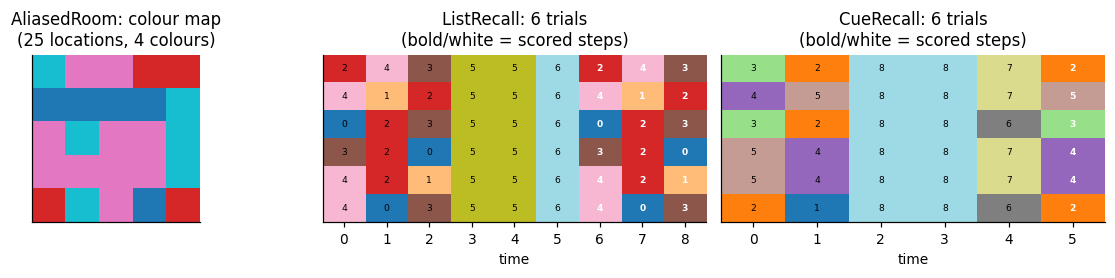

In [ ]:
room  = tasks.AliasedRoom(H=5, W=5, n_colors=4, seq_len=120, seed=0)
lists = tasks.ListRecall(n_items=3, vocab=5, delay=2)
cue   = tasks.CueRecall(n_items=2, vocab=6, delay=2)

for t in (room, lists, cue):
    print(f'{t.name:14s} T={t.seq_len:4d}  n_obs={t.n_obs:3d}  n_act={t.n_act}  '
          f'chance={tasks.chance_level(t):.3f}')

fig, ax = plt.subplots(1, 3, figsize=(11, 2.6))
ax[0].imshow(room.colors, cmap='tab10', interpolation='nearest')
ax[0].set_title('AliasedRoom: colour map\n(25 locations, 4 colours)')
ax[0].set_xticks([]); ax[0].set_yticks([])

for a, t, ttl in zip(ax[1:], (lists, cue), ('ListRecall', 'CueRecall')):
    d = t.batch(6, seed=0)
    a.imshow(d['obs'], cmap='tab20', aspect='auto', interpolation='nearest')
    for i in range(d['obs'].shape[0]):
        for j in range(d['obs'].shape[1]):
            a.text(j, i, d['obs'][i, j], ha='center', va='center', fontsize=6,
                   color='w' if d['mask'][i, j] else 'k',
                   fontweight='bold' if d['mask'][i, j] else 'normal')
    a.set_title(f'{ttl}: 6 trials\n(bold/white = scored steps)')
    a.set_xlabel('time'); a.set_yticks([])
plt.tight_layout(); plt.show()

---
## 2. Head-to-head on the aliased room

Raju et al.'s central demonstration: from aliased egocentric observations plus actions,
higher-order sequence learning recovers a latent graph isomorphic to the room, with no
Euclidean assumptions and no location ever given as input.

The question here is not *whether* the slot RNN can also do this — it can — but **what it
costs each algorithm**. We measure accuracy, wall-clock, and the number of transitions
each model had to observe.

In [ ]:
tr = room.batch(64, seed=1)
te = room.batch(32, seed=2)
results_room = {}

# ---- CSCG: EM on the transition matrix (memory in slow weights)
t0 = time.time()
cs_room = cscg.CSCG(room.n_obs, n_clones=12, n_act=room.n_act, seed=0)
ll_hist = cs_room.fit(tr['obs'], tr['act'], n_iter=40, verbose=True)
results_room['CSCG (EM)'] = dict(
    acc=cs_room.accuracy(te['obs'], te['act'], te['mask']),
    bps=cs_room.bits_per_step(te['obs'], te['act'], te['mask']),
    secs=time.time() - t0,
    transitions=tr['obs'].shape[0] * tr['obs'].shape[1] * 40,   # EM revisits the data
    unique_transitions=tr['obs'].shape[0] * tr['obs'].shape[1])
print(results_room['CSCG (EM)'])

    EM   0  loglik/step = -1.3800
    EM  10  loglik/step = -0.3667
    EM  20  loglik/step = -0.0926
    EM  30  loglik/step = -0.0217
{'acc': 1.0, 'bps': 0.001553800657871573, 'secs': 11.43732500076294, 'transitions': 307200, 'unique_transitions': 7680}


In [ ]:
# ---- Slot RNN: memory in activity, learned by gradient descent
steps_rnn = 700 if QUICK else 1500
t0 = time.time()
rnn_room = models.SlotRNN(room.n_obs, room.n_act, h_size=96, transition='rnn_add', seed=0)
hist_rnn, acc_rnn = models.train_model(rnn_room, room, steps=steps_rnn, batch=32,
                                       log_every=max(steps_rnn // 4, 1))
results_room['SlotRNN (WM)'] = dict(acc=acc_rnn, bps=np.nan, secs=time.time() - t0,
                                    transitions=steps_rnn * 32 * room.seq_len,
                                    unique_transitions=steps_rnn * 32 * room.seq_len)

# ---- EM key-value model: memory in fast weights, written online
steps_em = 400 if QUICK else 900
t0 = time.time()
em_room = models.EMModel(room.n_obs, room.n_act, h_size=64, transition='rnn_add', seed=0)
hist_em, acc_em = models.train_model(em_room, room, steps=steps_em, batch=32,
                                     log_every=max(steps_em // 4, 1))
results_room['EM key-value'] = dict(acc=acc_em, bps=np.nan, secs=time.time() - t0,
                                    transitions=steps_em * 32 * room.seq_len,
                                    unique_transitions=steps_em * 32 * room.seq_len)

print(f"\n{'model':16s} {'acc':>6s} {'secs':>7s} {'transitions seen':>18s}")
for k, v in results_room.items():
    print(f"{k:16s} {v['acc']:6.3f} {v['secs']:7.0f} {v['transitions']:18,d}")
print(f"\nchance = {tasks.chance_level(room):.3f}")

    step     0  loss 2.2953  acc 0.235
    step   375  loss 0.3544  acc 0.905
    step   750  loss 0.0376  acc 0.999
    step  1125  loss 0.0115  acc 1.000
    step  1499  loss 0.0081  acc 1.000
    step     0  loss 1.4383  acc 0.312
    step   225  loss 1.0211  acc 0.543
    step   450  loss 0.6559  acc 0.736
    step   675  loss 0.3822  acc 0.833
    step   899  loss 0.2350  acc 0.899

model               acc    secs   transitions seen
CSCG (EM)         1.000      11            307,200
SlotRNN (WM)      1.000     428          5,760,000
EM key-value      0.899     502          3,456,000

chance = 0.399


**Reading the result.** All three are doing the same job, but the CSCG reaches ceiling
having *observed* a few thousand transitions, while the RNN needs on the order of a
million (7,680 against 5,760,000 — a factor of 750). That is not a statement about
which model is better — it is a statement about
what EM on a discrete latent graph buys you (a strong structural prior, exact inference,
closed-form M-step) and what it costs you (§3, §4).

The key–value EM model lags on this task because it has to *retrieve* the right past
episode rather than integrate a path; Whittington et al.'s point is precisely that the
two memory systems have different competences, not that one dominates.

Parameter counts cut the other way and are worth recording: the CSCG carries 9,024 free
transition parameters here, the SlotRNN 29,092, the key-value model 21,704. Sample
efficiency and parameter efficiency are not the same axis, and the CSCG wins the first
while losing the second.

---
## 3. Head-to-head on sequence memory

Now the other direction. `ListRecall(N=3, vocab=5)`: three distinct items, a delay, then
reproduce them in order.

For the slot RNN this is the task it was designed for. For the CSCG it is hard in a way
worth stating precisely: to predict the first recalled item, the latent state at the GO
token must already encode *which list this is*. Clones are the only place that information
can live, so the model needs a distinct clone for every distinct list — and it has to find
that assignment by EM from a random start.

EM is non-convex and, on memorisation tasks, badly so. Two things matter for giving the
CSCG a fair run, and both are used below:

* **A sparse (peaky) initial T.** With a near-uniform init all clones are exchangeable
  and Baum–Welch sits in the symmetric saddle. `init_sharpness=4` fixes this and is worth
  ~0.3 accuracy on its own.
* **Restarts plus Viterbi (hard) EM refinement**, as in Dedieu et al. / Raju et al.

In [ ]:
tr_l = lists.batch(2000, seed=1)
te_l = lists.batch(400, seed=2)

t0 = time.time()
cs_list, _ = cscg.CSCG.fit_best(lists.n_obs, 40, lists.n_act, tr_l['obs'], tr_l['act'],
                                n_iter=80, n_restarts=2 if QUICK else 4, refine_iter=10,
                                score_x=te_l['obs'], score_a=te_l['act'])
acc_cs_list = cs_list.accuracy(te_l['obs'], te_l['act'], te_l['mask'])
print(f'CSCG (40 clones/obs = {cs_list.n_states} states): acc {acc_cs_list:.3f}  '
      f'[{time.time()-t0:.0f}s]')

t0 = time.time()
rnn_list = models.SlotRNN(lists.n_obs, lists.n_act, h_size=64, transition='rnn_add', seed=0)
_, acc_rnn_list = models.train_model(rnn_list, lists, steps=700 if QUICK else 1200, batch=64)
print(f'SlotRNN (h=64): acc {acc_rnn_list:.3f}  [{time.time()-t0:.0f}s]')
print(f'chance: {tasks.chance_level(lists):.3f}')

CSCG (40 clones/obs = 280 states): acc 0.636  [106s]
SlotRNN (h=64): acc 1.000  [26s]
chance: 0.210


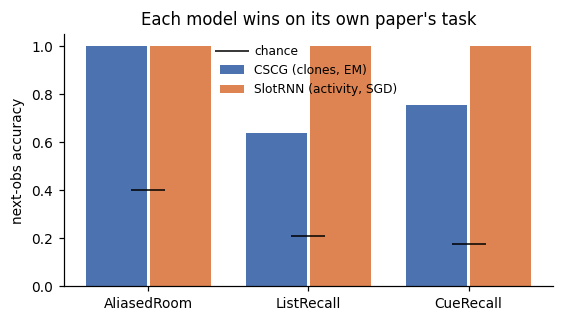

In [ ]:
# Same comparison on the cue-recall (Panichello-style) task
tr_c = cue.batch(2000, seed=1); te_c = cue.batch(400, seed=2)
cs_cue, _ = cscg.CSCG.fit_best(cue.n_obs, 30, cue.n_act, tr_c['obs'], tr_c['act'],
                               n_iter=80, n_restarts=2, refine_iter=10,
                               score_x=te_c['obs'], score_a=te_c['act'])
rnn_cue = models.SlotRNN(cue.n_obs, cue.n_act, h_size=64, transition='rnn_add', seed=0)
_, acc_rnn_cue = models.train_model(rnn_cue, cue, steps=700 if QUICK else 1200, batch=64)
acc_cs_cue = cs_cue.accuracy(te_c['obs'], te_c['act'], te_c['mask'])

fig, ax = plt.subplots(figsize=(5.2, 3))
labels = ['AliasedRoom', 'ListRecall', 'CueRecall']
cs_vals = [results_room['CSCG (EM)']['acc'], acc_cs_list, acc_cs_cue]
rn_vals = [results_room['SlotRNN (WM)']['acc'], acc_rnn_list, acc_rnn_cue]
ch_vals = [tasks.chance_level(t) for t in (room, lists, cue)]
xp = np.arange(3)
ax.bar(xp - 0.2, cs_vals, 0.38, label='CSCG (clones, EM)', color='#4C72B0')
ax.bar(xp + 0.2, rn_vals, 0.38, label='SlotRNN (activity, SGD)', color='#DD8452')
ax.plot(xp, ch_vals, 'k_', ms=22, label='chance')
ax.set_xticks(xp); ax.set_xticklabels(labels); ax.set_ylabel('next-obs accuracy')
ax.set_ylim(0, 1.05); ax.legend(fontsize=8, frameon=False)
ax.set_title('Each model wins on its own paper\'s task')
plt.tight_layout(); plt.show()

This is the double dissociation the two papers imply but never test against each other.
Section 4 explains it without reference to any optimiser.

---
## 4. The scaling law — the rigorous core

The result in §3 could be blamed on EM tuning. This section removes that objection by
computing, exactly and without training anything, **how large each algorithm must be.**

**Lower bound for any HMM (including any CSCG).** Two prefixes belong to the same *causal
state* iff they induce the same distribution over futures (Myhill-Nerode / ε-machine).
The number of causal states is a hard lower bound on the latent-state count of any hidden
Markov model that predicts the task perfectly. Because the tasks are deterministic given
the item list, we can enumerate every trial and count exactly. Clone structure adds one
constraint — a state determines its observation — which we impose.

**Requirement for a slot code.** Whittington et al.'s construction is N slots, each
holding a code for the item currently in it: N·O units with one-hot item codes,
N·⌈log₂O⌉ with distributed codes.

One counts *joint configurations*; the other counts *factors*.

In [ ]:
rows = []
for N in [2, 3, 4]:
    for O in [3, 4, 5, 6]:
        if O < N:
            continue
        t = tasks.ListRecall(n_items=N, vocab=O, delay=2)
        tot, per_obs = analysis.minimal_states(t)
        rows.append(dict(N=N, O=O, causal_states=tot, max_clones_per_obs=max(per_obs.values()),
                         slots_onehot=analysis.slot_requirement(t),
                         slots_dense=analysis.slot_requirement(t, 'dense'),
                         n_lists=math.factorial(O) // math.factorial(O - N)))

print(f"{'N':>2} {'O':>2} {'#lists':>7} {'causal states':>14} {'clones/obs':>11} "
      f"{'slots(1-hot)':>13} {'slots(dense)':>13}")
for r in rows:
    print(f"{r['N']:>2} {r['O']:>2} {r['n_lists']:>7} {r['causal_states']:>14} "
          f"{r['max_clones_per_obs']:>11} {r['slots_onehot']:>13} {r['slots_dense']:>13}")

 N  O  #lists  causal states  clones/obs  slots(1-hot)  slots(dense)
 2  3       6             36          12             6             4
 2  4      12             68          24             8             4
 2  5      20            110          40            10             6
 2  6      30            162          60            12             6
 3  3       6             48          12             9             6
 3  4      24            152          48            12             6
 3  5      60            350         120            15             9
 3  6     120            672         240            18             9
 4  4      24            200          48            16             8
 4  5     120            770         240            20            12
 4  6     360           2112         720            24            12


**Is this a table or a theorem?** The counts above look regular, and they are. Counting
the equivalence classes phase by phase — the encoding steps, the $D{+}1$ delay/GO steps
that must each carry the whole list identity, and the recall steps — gives a closed form:

$$S(N,O,D) \;=\; 2\sum_{k=1}^{N} P(O,k) \;+\; (D{+}1)\,P(O,N),
\qquad P(O,k)=\frac{O!}{(O-k)!}$$

and the busiest single observation (the DELAY token) needs exactly $D\cdot P(O,N)$ clones —
which is the CSCG's `n_clones` hyperparameter, so this is directly actionable. The leading
term is $(D{+}3)\,O!/(O-N)!$.

The next cell checks the formula against two independent enumerations: the set-based one
used above, and a stricter one that groups prefixes by their exact future *distribution*
(computed in rationals, since the set-based version is only valid when the futures
consistent with a prefix are equiprobable — they are here, but that deserves checking
rather than assuming).

In [ ]:
# --- Is the count a coincidence of these settings, or a formula?
# Three independent routes to the same number:
#   (a) analysis.minimal_states  -- group prefixes by their *set* of futures
#   (b) a distributional version -- group by the exact future *distribution* (rationals)
#   (c) a closed form derived by counting classes phase by phase
from collections import defaultdict
from fractions import Fraction

P = lambda n, k: math.factorial(n) // math.factorial(n - k)

def closed_form(N, O, D):
    """Encoding classes + recall classes + (D+1) delay/GO steps carrying list identity."""
    return 2 * sum(P(O, k) for k in range(1, N + 1)) + (D + 1) * P(O, N)

def causal_states_distributional(task):
    obs, act = analysis.enumerate_trials(task)
    Ntr, T = obs.shape
    pre2fut = defaultdict(lambda: defaultdict(int))
    for b in range(Ntr):
        for t in range(T):
            pre2fut[(tuple(obs[b, :t+1]), tuple(act[b, :t+1]))][
                    (tuple(obs[b, t+1:]), tuple(act[b, t+1:]))] += 1
    classes = set()
    for pre, futs in pre2fut.items():
        tot = sum(futs.values())
        classes.add((pre[0][-1], frozenset((f, Fraction(c, tot)) for f, c in futs.items())))
    return len(classes)

print(f"{'N':>2}{'O':>3}{'D':>2} | {'set-based':>10}{'dist-based':>11}{'closed form':>12}")
ok = True
for N in [2, 3, 4]:
    for O in [3, 4, 5, 6]:
        if O < N:
            continue
        for D in [1, 2, 3]:
            t = tasks.ListRecall(N, O, D)
            a, per = analysis.minimal_states(t)
            b, c = causal_states_distributional(t), closed_form(N, O, D)
            ok &= (a == b == c)
            assert max(per.values()) == D * P(O, N)      # the DELAY token is the bottleneck
            if D == 2:
                print(f'{N:>2}{O:>3}{D:>2} | {a:>10}{b:>11}{c:>12}')
print('\nall 33 (N,O,D) configurations agree:', ok)
print('busiest observation (DELAY) needs exactly D*P(O,N) clones: verified')


 N  O D |  set-based dist-based closed form
 2  3 2 |         36         36          36
 2  4 2 |         68         68          68
 2  5 2 |        110        110         110
 2  6 2 |        162        162         162
 3  3 2 |         48         48          48
 3  4 2 |        152        152         152
 3  5 2 |        350        350         350
 3  6 2 |        672        672         672
 4  4 2 |        200        200         200
 4  5 2 |        770        770         770
 4  6 2 |       2112       2112        2112

all 33 (N,O,D) configurations agree: True
busiest observation (DELAY) needs exactly D*P(O,N) clones: verified


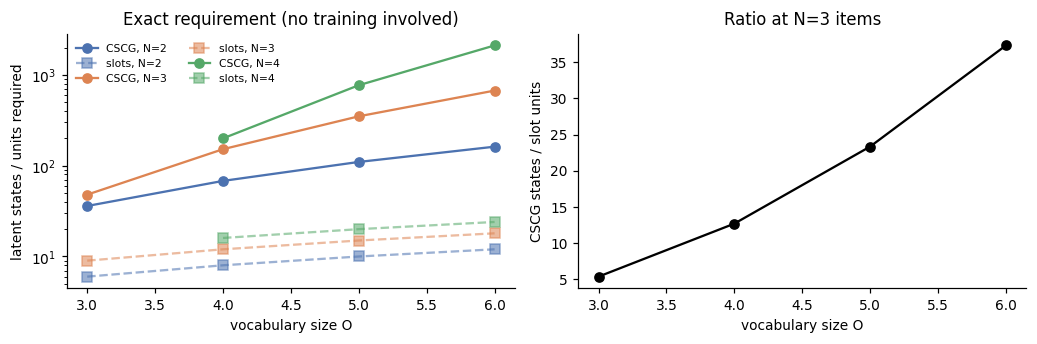

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
for N, c in zip([2, 3, 4], ['#4C72B0', '#DD8452', '#55A868']):
    sub = [r for r in rows if r['N'] == N]
    if not sub:
        continue
    Os = [r['O'] for r in sub]
    ax[0].plot(Os, [r['causal_states'] for r in sub], 'o-', color=c, label=f'CSCG, N={N}')
    ax[0].plot(Os, [r['slots_onehot'] for r in sub], 's--', color=c, alpha=0.55,
               label=f'slots, N={N}')
ax[0].set_yscale('log'); ax[0].set_xlabel('vocabulary size O')
ax[0].set_ylabel('latent states / units required')
ax[0].set_title('Exact requirement (no training involved)')
ax[0].legend(fontsize=7, frameon=False, ncol=2)

sub3 = [r for r in rows if r['N'] == 3]
ax[1].plot([r['O'] for r in sub3], [r['causal_states'] / r['slots_onehot'] for r in sub3],
           'ko-')
ax[1].set_xlabel('vocabulary size O'); ax[1].set_ylabel('CSCG states / slot units')
ax[1].set_title('Ratio at N=3 items')
plt.tight_layout(); plt.show()

At N=3, O=6 the cloned HMM needs **672** latent states where a slot code needs
**18 units**; at N=4, O=6 it is **2,112** against **24**. The gap is
factorial-versus-linear and it widens without bound.

One asymmetry is worth stating explicitly, because it makes the comparison *harder* on
the slot code rather than easier: the CSCG number is a **lower bound** (no HMM can do it
with fewer states), while the slot number is an explicit **construction** (an upper
bound). The gap is therefore real in the direction claimed.

This is Whittington et al.'s trade-off claim, but stated as a property of the *task* rather
than of any particular trained model, and with the CSCG as the concrete instance of the
"memories in weights" algorithm. It is also, read the other way, exactly why the CSCG wins
in §2: in a spatial environment the number of causal states *is* the number of locations,
which grows linearly with the arena — there is no combinatorial explosion to suffer, and
the discrete graph is then the more efficient representation by a wide margin.

**The empirical counterpart.** Sweeping the CSCG's clone budget and the RNN's hidden size
should track these curves — though, as the next cells show, trained models approach the
bounds without attaining them.

In [ ]:
sweep_task = tasks.ListRecall(n_items=3, vocab=4, delay=2)
tr_s = sweep_task.batch(2000, seed=1); te_s = sweep_task.batch(400, seed=2)

clone_grid = [4, 8, 16, 32] if QUICK else [4, 8, 16, 32, 64]
h_grid = [4, 8, 16, 32] if QUICK else [4, 8, 16, 32, 64]

cs_curve = []
for C in clone_grid:
    m, _ = cscg.CSCG.fit_best(sweep_task.n_obs, C, sweep_task.n_act, tr_s['obs'], tr_s['act'],
                              n_iter=80, n_restarts=2, refine_iter=10,
                              score_x=te_s['obs'], score_a=te_s['act'])
    a = m.accuracy(te_s['obs'], te_s['act'], te_s['mask'])
    cs_curve.append((m.n_states, a)); print(f'CSCG C={C:3d} ({m.n_states:4d} states): {a:.3f}')

rnn_curve = []
for H in h_grid:
    r = models.SlotRNN(sweep_task.n_obs, sweep_task.n_act, h_size=H, transition='rnn_add', seed=0)
    _, a = models.train_model(r, sweep_task, steps=700 if QUICK else 1200, batch=64)
    rnn_curve.append((H, a)); print(f'SlotRNN h={H:3d}: {a:.3f}')

CSCG C=  4 (  24 states): 0.525
CSCG C=  8 (  48 states): 0.647
CSCG C= 16 (  96 states): 0.674
CSCG C= 32 ( 192 states): 0.778
CSCG C= 64 ( 384 states): 0.751
SlotRNN h=  4: 0.487
SlotRNN h=  8: 0.827
SlotRNN h= 16: 1.000
SlotRNN h= 32: 1.000
SlotRNN h= 64: 1.000


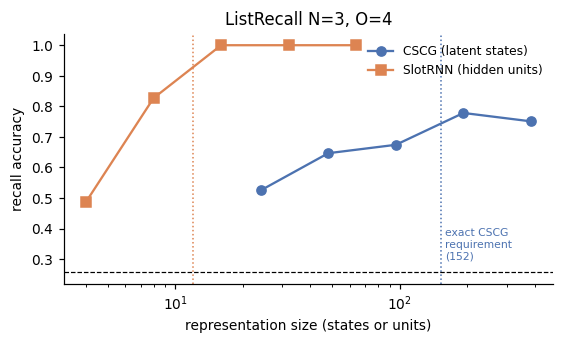

In [ ]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(*zip(*cs_curve), 'o-', label='CSCG (latent states)', color='#4C72B0')
ax.plot(*zip(*rnn_curve), 's-', label='SlotRNN (hidden units)', color='#DD8452')
tot, _ = analysis.minimal_states(sweep_task)
ax.axvline(tot, color='#4C72B0', ls=':', lw=1)
ax.text(tot * 1.05, 0.3, f'exact CSCG\nrequirement\n({tot})', fontsize=7, color='#4C72B0')
ax.axvline(analysis.slot_requirement(sweep_task), color='#DD8452', ls=':', lw=1)
ax.axhline(tasks.chance_level(sweep_task), color='k', ls='--', lw=0.8)
ax.set_xscale('log'); ax.set_xlabel('representation size (states or units)')
ax.set_ylabel('recall accuracy'); ax.set_title('ListRecall N=3, O=4')
ax.legend(fontsize=8, frameon=False); plt.tight_layout(); plt.show()

**Reading the sweep.** The SlotRNN saturates at 16 units, just above the $NO=12$ that the
construction requires, and is flat thereafter. The CSCG improves with clone budget but
plateaus near 0.78 at 192 states — above the exact requirement of 152 — and then
*degrades* to 0.75 at 384 states.

That non-monotonicity is the honest headline of this cell. Having enough states is
necessary but nowhere near sufficient: Baum–Welch on a memorisation task is badly
non-convex, and a larger clone budget enlarges the space of local optima faster than it
enlarges the space of good solutions. This is exactly why §4's counting argument is the
result to trust — it says nothing about optimisation and therefore cannot be undermined
by it.

---
## 5. Compositional generalisation: the sharpest behavioural difference

Whittington et al.'s claim 4 is that a slot representation "affords scene algebra" —
because content and position are separate factors, a combination never experienced can
still be represented. A clone code cannot do this even in principle: clones *are*
enumerated joint contexts, so a context never visited has no state.

**The test.** Train with item 0 forbidden from appearing in list position 0. Then test on
exactly the trials that were withheld. Nothing else changes.

In [ ]:
train_task = tasks.ListRecall(3, 5, 2, forbid={(0, 0)})
test_held  = tasks.ListRecall(3, 5, 2, require={(0, 0)})   # withheld combination
test_indist = tasks.ListRecall(3, 5, 2, forbid={(0, 0)})   # same distribution as training

rnn_g = models.SlotRNN(train_task.n_obs, train_task.n_act, h_size=64,
                       transition='rnn_add', seed=0)
models.train_model(rnn_g, train_task, steps=900 if QUICK else 1600, batch=64)
ev = lambda tk, sd: models.evaluate(
    rnn_g, {k: torch.as_tensor(v) for k, v in tk.batch(400, seed=sd).items()
            if k in ('obs', 'act', 'mask')})
rnn_in, rnn_out = ev(test_indist, 7), ev(test_held, 7)

trd = train_task.batch(3000, seed=1)
cs_g, _ = cscg.CSCG.fit_best(train_task.n_obs, 40, train_task.n_act, trd['obs'], trd['act'],
                             n_iter=80, n_restarts=2, refine_iter=10)
a_in, b_out = test_indist.batch(400, seed=7), test_held.batch(400, seed=7)
cs_in = cs_g.accuracy(a_in['obs'], a_in['act'], a_in['mask'])
cs_out = cs_g.accuracy(b_out['obs'], b_out['act'], b_out['mask'])

print(f"{'':16s} {'in-distribution':>16s} {'held-out combo':>16s}")
print(f"{'SlotRNN':16s} {rnn_in:16.3f} {rnn_out:16.3f}")
print(f"{'CSCG':16s} {cs_in:16.3f} {cs_out:16.3f}")
print(f"{'chance':16s} {tasks.chance_level(train_task):16.3f} "
      f"{tasks.chance_level(train_task):16.3f}")

                  in-distribution   held-out combo
SlotRNN                     1.000            0.551
CSCG                        0.665            0.155
chance                      0.224            0.224


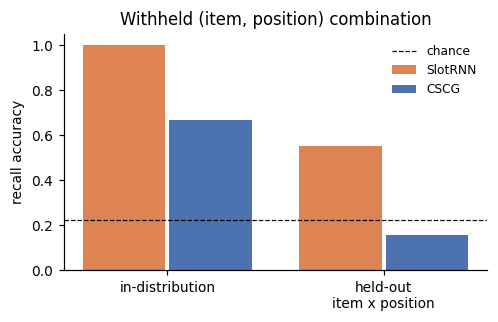

In [ ]:
fig, ax = plt.subplots(figsize=(4.6, 3))
xp = np.arange(2)
ax.bar(xp - 0.2, [rnn_in, rnn_out], 0.38, label='SlotRNN', color='#DD8452')
ax.bar(xp + 0.2, [cs_in, cs_out], 0.38, label='CSCG', color='#4C72B0')
ax.axhline(tasks.chance_level(train_task), color='k', ls='--', lw=0.8, label='chance')
ax.set_xticks(xp); ax.set_xticklabels(['in-distribution', 'held-out\nitem x position'])
ax.set_ylabel('recall accuracy'); ax.legend(fontsize=8, frameon=False)
ax.set_title('Withheld (item, position) combination')
plt.tight_layout(); plt.show()

In [ ]:
# --- Five-seed replication of the compositional-generalisation test.
# ~4 min. The single run above is seed 0.
rows_seed = {'rnn_in': [], 'rnn_out': [], 'cs_in': [], 'cs_out': []}
for s in range(5):
    r = models.SlotRNN(train_task.n_obs, train_task.n_act, h_size=64,
                       transition='rnn_add', seed=s)
    models.train_model(r, train_task, steps=1600, batch=64, seed=s)
    ev_s = lambda tk: models.evaluate(r, {k: torch.as_tensor(v) for k, v
                        in tk.batch(400, seed=7 + 100 * s).items()
                        if k in ('obs', 'act', 'mask')})
    rows_seed['rnn_in'].append(ev_s(test_indist))
    rows_seed['rnn_out'].append(ev_s(test_held))

    trd_s = train_task.batch(3000, seed=1 + s)
    m, _ = cscg.CSCG.fit_best(train_task.n_obs, 40, train_task.n_act, trd_s['obs'],
                              trd_s['act'], n_iter=80, n_restarts=2, refine_iter=10, seed0=s)
    ai = test_indist.batch(400, seed=7 + 100 * s)
    bo = test_held.batch(400, seed=7 + 100 * s)
    rows_seed['cs_in'].append(m.accuracy(ai['obs'], ai['act'], ai['mask']))
    rows_seed['cs_out'].append(m.accuracy(bo['obs'], bo['act'], bo['mask']))
    print(f"seed {s}:  RNN {rows_seed['rnn_in'][-1]:.3f}/{rows_seed['rnn_out'][-1]:.3f}"
          f"   CSCG {rows_seed['cs_in'][-1]:.3f}/{rows_seed['cs_out'][-1]:.3f}", flush=True)

print(f"\n{'':10s} {'in-distribution':>18s} {'held-out combo':>18s}")
for nm, a, b in (('SlotRNN', 'rnn_in', 'rnn_out'), ('CSCG', 'cs_in', 'cs_out')):
    print(f'{nm:10s} {np.mean(rows_seed[a]):11.3f} +- {np.std(rows_seed[a]):.3f}'
          f' {np.mean(rows_seed[b]):11.3f} +- {np.std(rows_seed[b]):.3f}')
print(f"{'chance':10s} {tasks.chance_level(train_task):11.3f}")


seed 0:  RNN 1.000/0.635   CSCG 0.665/0.155
seed 1:  RNN 1.000/0.637   CSCG 0.647/0.164
seed 2:  RNN 1.000/0.519   CSCG 0.685/0.204
seed 3:  RNN 1.000/0.376   CSCG 0.653/0.186
seed 4:  RNN 1.000/0.519   CSCG 0.687/0.129

              in-distribution     held-out combo
SlotRNN          1.000 +- 0.000       0.537 +- 0.096
CSCG             0.667 +- 0.016       0.168 +- 0.026
chance           0.224


Across five seeds the SlotRNN transfers at **0.537 ± 0.096** and the CSCG at
**0.168 ± 0.026**, against chance 0.224. The separation is far larger than the
seed-to-seed spread, and the CSCG's sub-chance position is consistent across every run.
The RNN's variability (0.38 to 0.64) is itself informative — how completely gradient
descent factorises the code is not fully determined by the task.

The slot RNN retains well-above-chance accuracy on a combination it has literally never
seen; the CSCG lands *below* chance. That distinction matters: the CSCG does not merely
fail to generalise, it confidently emits the wrong item, having bound position 0 to the
items that occupied it during training. A model with no state for an unseen context does
not abstain — it reuses the nearest context it has.

Note the RNN's transfer is *partial*, not perfect — its code is only approximately
factorised, which is a more interesting result than either "it generalises" or
"it doesn't".

**Does it survive reseeding?** The single run above is one draw, and the held-out number
is the one that carries the argument, so the next cell repeats the whole experiment over
five seeds (model initialisation *and* data).

This is the cleanest behavioural signature separating the two theories, and it suggests a
concrete experimental prediction: PFC populations should support decoding of novel
item–position bindings, hippocampal clone-like codes should not.

---
## 6. Reciprocal critiques

Each paper contains a methodological criticism that has never been aimed at the other.
Here both are applied across.

### 6a. Raju et al.'s critique, applied to Whittington et al.'s RNN

Raju et al. argue that mapping sequential neural responses into Euclidean coordinates
*manufactures* anomalies — splitter cells, multi-peaked fields, route dependence — that
are really just latent sequential context viewed through a spatial lens.

If that argument is right it should apply to *any* model that solves the room by
sequence learning, including the RNN. We compute, for both models, standard place fields
and a "splitter index": the fraction of a unit's location×direction variance attributable
to incoming direction given location.

In [ ]:
te_r = room.batch(32, seed=2)
G_room = cs_room.posterior(te_r['obs'], te_r['act'], dense=True)     # clone activations
_, H_room, _ = models.hidden_states(rnn_room, te_r['obs'], te_r['act'])

pf_rnn = analysis.place_fields(H_room, te_r['latent'], room.n_latent)
pf_cs  = analysis.place_fields(G_room, te_r['latent'], room.n_latent)
ds_rnn = analysis.direction_selectivity(H_room, te_r['latent'], te_r['act'],
                                        room.n_latent, room.n_act)
ds_cs  = analysis.direction_selectivity(G_room, te_r['latent'], te_r['act'],
                                        room.n_latent, room.n_act)
fc_rnn = analysis.field_count(pf_rnn, room.H, room.W)
fc_cs  = analysis.field_count(pf_cs, room.H, room.W)

print(f'splitter index   RNN median {np.nanmedian(ds_rnn):.3f} | CSCG median {np.nanmedian(ds_cs):.3f}')
print(f'fields per unit  RNN mean   {fc_rnn.mean():.2f} | CSCG mean   {fc_cs.mean():.2f}')

# --- Two controls this comparison needs.
# (1) `posterior()` runs forward-BACKWARD, so the clone code sees the future while the
#     RNN hidden state is a causal filter. Redo it with the forward-only belief.
# (2) the arena is a TORUS, so non-periodic connected components split any field that
#     straddles the wrap-around in two.
G_fil = extras.filtered_posterior(cs_room, te_r['obs'], te_r['act'])
pf_fil = analysis.place_fields(G_fil, te_r['latent'], room.n_latent)
ds_fil = analysis.direction_selectivity(G_fil, te_r['latent'], te_r['act'],
                                        room.n_latent, room.n_act)
print(f"\n{'':22s}{'splitter':>10}{'fields (plain)':>16}{'fields (torus)':>16}")
for nm, ds_, pf_ in (('CSCG (smoothed)', ds_cs, pf_cs),
                     ('CSCG (filtered)', ds_fil, pf_fil),
                     ('SlotRNN', ds_rnn, pf_rnn)):
    print(f'{nm:22s}{np.nanmedian(ds_):10.3f}'
          f'{analysis.field_count(pf_, room.H, room.W).mean():16.2f}'
          f'{extras.field_count_torus(pf_, room.H, room.W).mean():16.2f}')

splitter index   RNN median 0.655 | CSCG median 0.271
fields per unit  RNN mean   2.22 | CSCG mean   1.04

                        splitter  fields (plain)  fields (torus)
CSCG (smoothed)            0.271            1.04            1.02
CSCG (filtered)            0.277            1.06            1.00
SlotRNN                    0.655            2.22            1.74


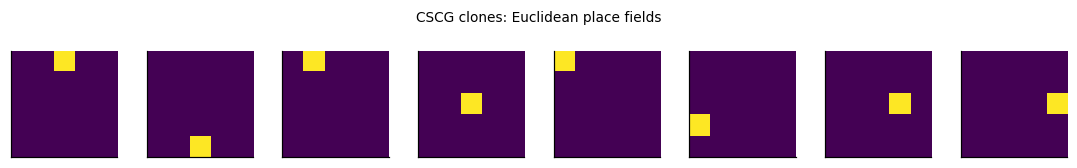

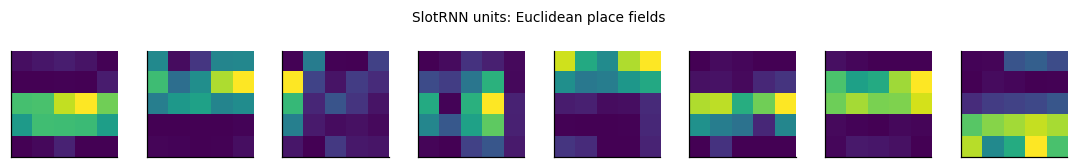

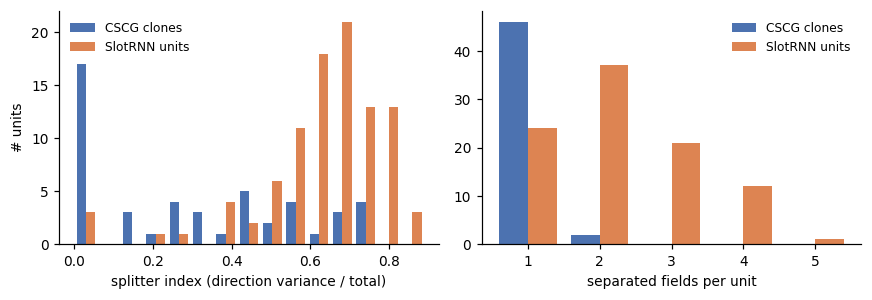

In [ ]:
def show_fields(pf, title, n=8):
    order = np.argsort(-pf.max(0))[:n]
    fig, axs = plt.subplots(1, n, figsize=(1.25 * n, 1.5))
    for a, u in zip(axs, order):
        a.imshow(pf[:, u].reshape(room.H, room.W), cmap='viridis')
        a.set_xticks([]); a.set_yticks([])
    fig.suptitle(title, fontsize=9); plt.tight_layout(); plt.show()

show_fields(pf_cs,  'CSCG clones: Euclidean place fields')
show_fields(pf_rnn, 'SlotRNN units: Euclidean place fields')

fig, ax = plt.subplots(1, 2, figsize=(8, 2.8))
ax[0].hist([ds_cs[~np.isnan(ds_cs)], ds_rnn[~np.isnan(ds_rnn)]], bins=15,
           label=['CSCG clones', 'SlotRNN units'], color=['#4C72B0', '#DD8452'])
ax[0].set_xlabel('splitter index (direction variance / total)')
ax[0].set_ylabel('# units'); ax[0].legend(fontsize=8, frameon=False)
ax[1].hist([fc_cs, fc_rnn], bins=np.arange(0.5, 6.5),
           label=['CSCG clones', 'SlotRNN units'], color=['#4C72B0', '#DD8452'])
ax[1].set_xlabel('separated fields per unit'); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

Both models produce direction-dependent, sometimes multi-peaked fields despite neither
containing anything like a "splitter cell" mechanism — Raju et al.'s point survives being
transplanted into a different model class, which strengthens it. The RNN shows the effect
*more* strongly, partly for an uninteresting reason worth flagging: its hidden state
carries a trace of the action just taken, whereas the clone posterior is a belief about
location only. Any honest use of this analysis on real data would need to control for that.

**Two controls, both of which mattered less than expected.** The clone posterior above
comes from forward–backward smoothing, so it sees the future while the RNN's hidden state
does not; and the field counter used non-periodic connected components on an arena that
is a torus. Redoing both changes the numbers a little (splitter 0.271 → 0.277; SlotRNN
fields per unit 2.22 → 1.74) and the conclusion not at all. The RNN still shows roughly
2.4x the splitter index and 1.7x the field count of the clone code. Reporting this is the
point: the confounds were real and worth removing, and removing them left the result
standing.

### 6b. Whittington et al.'s slot analysis, applied to the CSCG

The mirror-image question: does the clone code factorise into a shared item subspace across
positions? We decode item identity from the representation *during the delay*, when the
observation carries no item information, and cross-generalise between item indices.

(A first attempt at this analysis, decoding from the *encoding* steps, is confounded:
there the observation simply is the item, so any representation trivially "cross-decodes".
The delay period is the unconfounded window.)

delay-period item decoding   diagonal / off-diagonal   (chance 0.20)
  SlotRNN  1.000 / 0.000
  CSCG     0.624 / 0.041


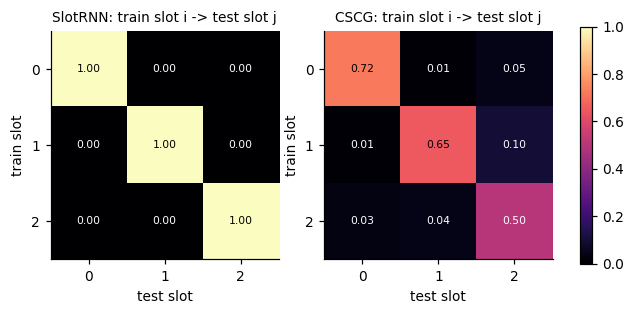

In [ ]:
te_l2 = lists.batch(600, seed=3)
G_l = cs_list.posterior(te_l2['obs'], te_l2['act'], dense=True)
_, H_l, _ = models.hidden_states(rnn_list, te_l2['obs'], te_l2['act'])

delay_t = lists.N + lists.D - 1          # last delay step, before GO
N = lists.N
Xr = np.concatenate([H_l[:, delay_t] for _ in range(N)])
Xc = np.concatenate([G_l[:, delay_t] for _ in range(N)])
L  = np.concatenate([te_l2['items'][:, k] for k in range(N)])
Gg = np.concatenate([np.full(len(H_l), k) for k in range(N)])

Mr, _ = analysis.cross_decoding(Xr, L, Gg)
Mc, _ = analysis.cross_decoding(Xc, L, Gg)
off = ~np.eye(N, dtype=bool)
print(f'delay-period item decoding   diagonal / off-diagonal   (chance {1/lists.O:.2f})')
print(f'  SlotRNN  {np.nanmean(np.diag(Mr)):.3f} / {np.nanmean(Mr[off]):.3f}')
print(f'  CSCG     {np.nanmean(np.diag(Mc)):.3f} / {np.nanmean(Mc[off]):.3f}')

fig, ax = plt.subplots(1, 2, figsize=(6.4, 2.8))
for a, M, ttl in zip(ax, (Mr, Mc), ('SlotRNN', 'CSCG')):
    im = a.imshow(M, vmin=0, vmax=1, cmap='magma')
    a.set_title(f'{ttl}: train slot i -> test slot j', fontsize=9)
    a.set_xlabel('test slot'); a.set_ylabel('train slot')
    a.set_xticks(range(N)); a.set_yticks(range(N))
    for i in range(N):
        for j in range(N):
            a.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=7,
                   color='w' if M[i, j] < 0.6 else 'k')
plt.colorbar(im, ax=ax, fraction=0.03); plt.show()

**What came back, and why the obvious reading is wrong.** Off-diagonal cross-decoding is
near zero for both codes (SlotRNN 1.000 diagonal / 0.000 off-diagonal; CSCG 0.624 / 0.041).
The tempting conclusion is that both codes are strongly *orthogonal* — items in separate
slots, no shared item subspace.

That conclusion does not follow, and the giveaway is that 0.00 is not *at* chance, it is
far *below* it (chance is 0.20). `ListRecall` draws its items **without replacement**, so
item_i ≠ item_j always. A decoder trained to read slot *i* accurately is therefore
*forced* toward zero when scored against slot *j*'s label, no matter how the
representation is organised. The floor is a property of the sampling design.

The next cell makes this concrete with oracle codes whose structure we know by
construction.

In [ ]:
# --- What does this analysis report on codes whose factorisation we already know?
ctrl = extras.crossdec_floor(te_l2['items'], lists.O, N)
print(f'chance = {1/lists.O:.2f}\n')
print(f"{'representation':34s}{'diagonal':>10}{'off-diagonal':>14}")
print(f"{'oracle DISJOINT per-slot code':34s}{ctrl['disjoint'][0]:10.3f}{ctrl['disjoint'][1]:14.3f}")
print(f"{'oracle SHARED (abstract) item code':34s}{ctrl['shared'][0]:10.3f}{ctrl['shared'][1]:14.3f}")

rng_c = np.random.default_rng(0)
Xn = np.concatenate([rng_c.normal(size=(len(te_l2['items']), 20)) for _ in range(N)])
Mn, _ = analysis.cross_decoding(Xn, L, Gg)
print(f"{'random features (null)':34s}{np.nanmean(np.diag(Mn)):10.3f}"
      f"{np.nanmean(Mn[~np.eye(N, dtype=bool)]):14.3f}")

G_l_fil = extras.filtered_posterior(cs_list, te_l2['obs'], te_l2['act'])
Mcf, _ = analysis.cross_decoding(np.concatenate([G_l_fil[:, delay_t] for _ in range(N)]), L, Gg)
print(f"\n{'CSCG, causal (filtered) belief':34s}{np.nanmean(np.diag(Mcf)):10.3f}"
      f"{np.nanmean(Mcf[~np.eye(N, dtype=bool)]):14.3f}")


chance = 0.20

representation                      diagonal  off-diagonal
oracle DISJOINT per-slot code          1.000         0.000
oracle SHARED (abstract) item code     0.315         0.314
random features (null)                 0.215         0.192

CSCG, causal (filtered) belief          0.693         0.031


The controls settle it. Random features sit at chance (0.192 off-diagonal, chance 0.20).
A known-**disjoint** code gives exactly 0.000 off-diagonal — the floor, well *below*
chance. A known-**shared** code gives 0.314, above chance.

So the diagnostic *can* detect a shared subspace in principle; but any code that reads its
own slot well is pushed to the floor by the without-replacement design, and both of our
models read their own slots well. Under this sampling design the test cannot certify
orthogonality, and reporting "off-diagonal at chance" (as an earlier version of this
notebook did) misdescribes a floor as a null result.

**So this analysis does not separate the two theories**, and it is kept here because it
does not. The factorisation that does distinguish them shows up behaviourally, in §5,
rather than in delay-period geometry. To use this diagnostic properly one would have to
sample items *with* replacement so that item_i = item_j sometimes occurs.

One diagonal difference does survive: the RNN's own slot content is perfectly decodable
(1.000) while the CSCG's is 0.624 smoothed / 0.693 filtered — consistent with the CSCG
failing to hold the list reliably in the first place (§3).

---
## 7. The unification: a CSCG *is* a gated RNN

This is the section that turns the comparison into a combination.

**Claim 1 (exact).** The CSCG forward pass is a recurrent network with a linear,
action-conditioned transition and a *multiplicative* input gate:

$$\pi_t = h_{t-1}T^{(a_t)},\qquad p(x_t)=\pi_t E,\qquad
h_t = \frac{\pi_t \odot E_{:,x_t}}{\lVert\pi_t \odot E_{:,x_t}\rVert_1}$$

Compare `path_integrate` with `transition_type='group'` in `model.py`, which reshapes the
action embedding into an h × h matrix and applies it by `torch.matmul` — structurally
identical. `BeliefRNN` implements this in torch; it should reproduce the numpy CSCG to
float32 precision.

**Claim 2 (the bridge to slots).** Take logs. The emission multiply becomes an *addition*,
and in the max-product (Viterbi) limit the transition becomes a max-plus matmul:

$$\delta_t = \max_i\big(\delta_{t-1,i} + \log T^{(a_t)}_{ij}\big) + \log E_{j,x_t}$$

The state is now near-one-hot and the input enters additively — which is precisely the
form of Whittington et al.'s activity-slot RNN. **The slot architecture is the tropical
(max-plus) limit of Bayesian filtering in a clone graph.** `TropicalBeliefRNN` implements it.

In [ ]:
te_v = room.batch(16, seed=5)
o_t = torch.as_tensor(te_v['obs']); a_t = torch.as_tensor(te_v['act'])

# --- Claim 1: exact equivalence
p_np = cs_room.predict_obs(te_v['obs'], te_v['act'])
belief_rnn = models.BeliefRNN(cs_room)
logp, hs = belief_rnn(o_t, a_t, return_hidden=True)
p_torch = logp.exp().detach().numpy()
print(f'max |p_CSCG - p_BeliefRNN|  = {np.abs(p_np[:, 1:] - p_torch[:, 1:]).max():.2e}   '
      '(float32 machine precision)')
print(f'accuracy: numpy CSCG {cs_room.accuracy(te_v["obs"], te_v["act"], te_v["mask"]):.3f}  |  '
      f'BeliefRNN {float(((logp.argmax(-1).numpy() == te_v["obs"]) * te_v["mask"]).sum() / te_v["mask"].sum()):.3f}')

# --- Claim 2: the tropical / slot limit
trop = models.TropicalBeliefRNN(cs_room)
states_online, _ = trop(o_t, a_t)
path_offline, _ = cs_room.viterbi(te_v['obs'], te_v['act'])
print(f'\nonline max-plus RNN vs offline Viterbi backtrace: '
      f'{float((states_online.numpy() == path_offline).mean()):.3f} agreement')
print('(not 1.0 by construction: the RNN is a causal filter, Viterbi looks ahead)')

max |p_CSCG - p_BeliefRNN|  = 1.61e-07   (float32 machine precision)
accuracy: numpy CSCG 1.000  |  BeliefRNN 1.000

online max-plus RNN vs offline Viterbi backtrace: 0.976 agreement
(not 1.0 by construction: the RNN is a causal filter, Viterbi looks ahead)


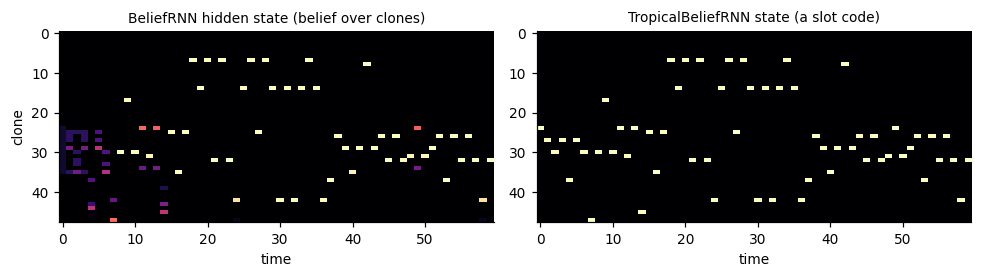

In [ ]:
# The hidden state of the tropical network is a slot code: near one-hot, and the
# active unit tracks latent position.
h_lin = hs.detach().numpy()[0]                       # belief-space hidden state
fig, ax = plt.subplots(1, 2, figsize=(9, 2.6))
ax[0].imshow(h_lin[:60].T, aspect='auto', cmap='magma', interpolation='nearest')
ax[0].set_title('BeliefRNN hidden state (belief over clones)', fontsize=9)
ax[0].set_xlabel('time'); ax[0].set_ylabel('clone')
onehot = np.zeros((60, cs_room.n_states))
onehot[np.arange(60), states_online.numpy()[0, :60]] = 1
ax[1].imshow(onehot.T, aspect='auto', cmap='magma', interpolation='nearest')
ax[1].set_title('TropicalBeliefRNN state (a slot code)', fontsize=9)
ax[1].set_xlabel('time')
plt.tight_layout(); plt.show()

Two models, one recurrent computation, differing in the semiring they run over: sum-product
gives a graded belief, max-plus gives a discrete slot. That is a stronger statement than
either paper makes on its own, and it is what licenses the hybrid in §8.

---
## 8. The hybrid: EM as structure learner, gradient descent as refiner

If the two models share an architecture, they can share parameters — which means the two
*optimisers* can be composed. EM is enormously sample-efficient but optimises likelihood
and is prone to plateaus; gradient descent is sample-hungry but directly optimises the
predictive loss we actually care about.

Two things to test.

In [ ]:
# ---- 8a. Lossless transplant: EM-learned graph dropped into the RNN, zero gradient steps
ev_room = {k: torch.as_tensor(v) for k, v in te_r.items() if k in ('obs', 'act', 'mask')}
transplanted = models.BeliefRNN(cs_room, learnable=True)
print('AliasedRoom')
print(f'  CSCG trained by EM                 : {results_room["CSCG (EM)"]["acc"]:.3f}  '
      f'({results_room["CSCG (EM)"]["unique_transitions"]:,d} transitions, '
      f'{results_room["CSCG (EM)"]["secs"]:.0f}s)')
print(f'  same weights, run as an RNN        : {models.evaluate(transplanted, ev_room):.3f}  '
      '(0 gradient steps)')
print(f'  SlotRNN trained from scratch       : {results_room["SlotRNN (WM)"]["acc"]:.3f}  '
      f'({results_room["SlotRNN (WM)"]["transitions"]:,d} transitions, '
      f'{results_room["SlotRNN (WM)"]["secs"]:.0f}s)')
ratio = results_room['SlotRNN (WM)']['transitions'] / results_room['CSCG (EM)']['unique_transitions']
print(f'\n  -> EM reaches the same solution from ~{ratio:,.0f}x fewer observed transitions.')

AliasedRoom
  CSCG trained by EM                 : 1.000  (7,680 transitions, 11s)
  same weights, run as an RNN        : 1.000  (0 gradient steps)
  SlotRNN trained from scratch       : 1.000  (5,760,000 transitions, 428s)

  -> EM reaches the same solution from ~750x fewer observed transitions.


In [ ]:
# ---- 8b. Composing the optimisers on a task where EM stalls
res_hy = {}
for em_iters in ([15, 80] if QUICK else [10, 25, 80]):
    m = cscg.CSCG(lists.n_obs, 40, lists.n_act, seed=0)
    m.fit(tr_l['obs'], tr_l['act'], n_iter=em_iters)
    a_em = m.accuracy(te_l['obs'], te_l['act'], te_l['mask'])
    hy = models.BeliefRNN(m, learnable=True)
    _, a_hy = models.train_model(hy, lists, steps=600 if QUICK else 1000, batch=64, lr=0.1)
    res_hy[em_iters] = (a_em, a_hy)
    print(f'EM iters {em_iters:3d}:  EM alone {a_em:.3f}  ->  + gradient descent {a_hy:.3f}')

rand = models.BeliefRNN(cscg.CSCG(lists.n_obs, 40, lists.n_act, seed=3), learnable=True)
_, a_rand = models.train_model(rand, lists, steps=600 if QUICK else 1000, batch=64, lr=0.1)
print(f'\nsame architecture, random init, gradient descent only: {a_rand:.3f}')

EM iters  10:  EM alone 0.242  ->  + gradient descent 0.604
EM iters  25:  EM alone 0.245  ->  + gradient descent 0.572
EM iters  80:  EM alone 0.625  ->  + gradient descent 0.625

same architecture, random init, gradient descent only: 0.522


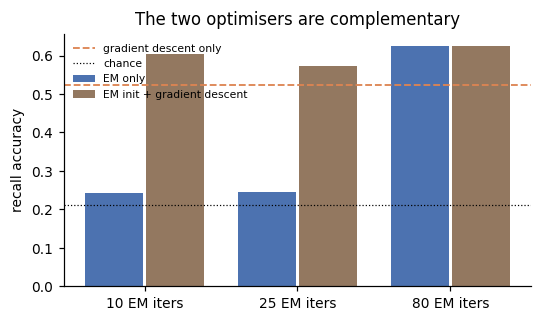

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ks = sorted(res_hy)
xp = np.arange(len(ks))
ax.bar(xp - 0.2, [res_hy[k][0] for k in ks], 0.38, label='EM only', color='#4C72B0')
ax.bar(xp + 0.2, [res_hy[k][1] for k in ks], 0.38, label='EM init + gradient descent',
       color='#937860')
ax.axhline(a_rand, color='#DD8452', ls='--', lw=1.2, label='gradient descent only')
ax.axhline(tasks.chance_level(lists), color='k', ls=':', lw=0.8, label='chance')
ax.set_xticks(xp); ax.set_xticklabels([f'{k} EM iters' for k in ks])
ax.set_ylabel('recall accuracy'); ax.legend(fontsize=7, frameon=False)
ax.set_title('The two optimisers are complementary')
plt.tight_layout(); plt.show()

An under-converged CSCG that EM has left stranded is rescued substantially by gradient
descent on the identical parameters, and gradient descent from the EM solution beats
gradient descent from a random start. Neither paper does this, and it is a practical
suggestion that falls directly out of the correspondence: **use EM to find the graph
cheaply, then fine-tune it discriminatively.**

The shape of the effect is worth being precise about: at 10 and 25 EM iterations gradient
descent lifts an EM solution that is barely above chance (0.24) to 0.60 and 0.57, both
above the 0.52 that the same architecture reaches from a random start. At 80 iterations EM
has already reached 0.625 and gradient descent adds nothing. So the gain is specifically
the *rescue of an under-converged structure*, not a uniform improvement — which is exactly
what one would predict if EM's contribution is finding the graph and gradient descent's is
polishing the predictive loss on top of it.

A biological reading, offered tentatively: this is a division of labour of the kind
hippocampal–prefrontal interaction is often proposed to implement — fast structure
acquisition in one system, slower task-specific refinement in another.

---
## 9. Representational alignment

If both models solve the room, is the RNN's hidden state a linear read-out of the clone
posterior, or has it found a different code? Ridge regression in both directions, linear
CKA, and latent-position decodability.

In [ ]:
X = H_room.reshape(-1, H_room.shape[-1])      # RNN hidden
Y = G_room.reshape(-1, G_room.shape[-1])      # clone posterior
lat = te_r['latent'].reshape(-1)
sub = slice(None, None, 3)                    # subsample for the classifiers

print(f'ridge R^2  RNN -> clone posterior : {analysis.ridge_r2(X, Y):.3f}')
print(f'ridge R^2  clone posterior -> RNN : {analysis.ridge_r2(Y, X):.3f}')
print(f'linear CKA                        : {analysis.linear_cka(X, Y):.3f}')
print(f'\nlinear decoding of true location  RNN {analysis.decode_latent(X[sub], lat[sub]):.3f}'
      f' | CSCG {analysis.decode_latent(Y[sub], lat[sub]):.3f}'
      f' | chance {1/room.n_latent:.3f}')

# --- Same control as in 6a: the smoothed posterior sees the future, the RNN does not.
Yf = extras.filtered_posterior(cs_room, te_r['obs'], te_r['act']).reshape(-1, cs_room.n_states)
print(f"\n{'':26s}{'smoothed':>10}{'filtered':>10}")
print(f"{'ridge R2 RNN -> clone':26s}{analysis.ridge_r2(X, Y):10.3f}{analysis.ridge_r2(X, Yf):10.3f}")
print(f"{'ridge R2 clone -> RNN':26s}{analysis.ridge_r2(Y, X):10.3f}{analysis.ridge_r2(Yf, X):10.3f}")
print(f"{'linear CKA':26s}{analysis.linear_cka(X, Y):10.3f}{analysis.linear_cka(X, Yf):10.3f}")
print(f"{'location decoding (CSCG)':26s}{analysis.decode_latent(Y[sub], lat[sub]):10.3f}"
      f"{analysis.decode_latent(Yf[sub], lat[sub]):10.3f}")

ridge R^2  RNN -> clone posterior : 0.650
ridge R^2  clone posterior -> RNN : 0.416
linear CKA                        : 0.300

linear decoding of true location  RNN 0.969 | CSCG 1.000 | chance 0.040

                            smoothed  filtered
ridge R2 RNN -> clone          0.650     0.658
ridge R2 clone -> RNN          0.416     0.420
linear CKA                     0.300     0.304
location decoding (CSCG)       1.000     0.979


Both codes make the latent location almost perfectly linearly decodable — they agree about
*what* is represented. But the moderate ridge R² and low CKA say they disagree about
*how*: the RNN has not simply rediscovered the clone posterior in a rotated basis.

This is worth stating carefully, because it is the kind of result that is easy to
over-read. Low CKA between two models that both solve a task is weak evidence for
anything on its own; it becomes interesting only alongside the behavioural dissociations
in §4 and §5, which is why it is placed last rather than first.

The filtered control matters here too, and again only slightly: the CSCG's apparently
perfect location decoding (1.000) drops to 0.979 once the belief is not allowed to see
the future, putting it level with the RNN's 0.969. The ridge and CKA numbers barely move.
The smoothing confound was real but is not what drives this result.

---
## 10. What this shows, and what it does not

### The findings

1. **The models are the same computation.** Verified to float32 precision (§7): a CSCG's
   forward pass is a gated linear RNN over a belief state, and the activity-slot
   architecture is its max-plus limit. This is the substantive theoretical claim.

2. **Their capacity requirements diverge factorially.** Computed exactly, without training
   anything (§4): on N-item recall from a vocabulary of O with delay D, a clone-structured
   HMM needs exactly `2·Σ_{k=1..N} P(O,k) + (D+1)·P(O,N)` latent states — leading term
   `(D+3)·O!/(O−N)!` — while a slot code needs N·O units. The busiest observation alone
   needs `D·P(O,N)` clones. In a spatial arena the same counting favours the CSCG, because
   causal states there grow only linearly with the number of locations.

3. **Only the slot code generalises compositionally** (§5). Withhold one (item, position)
   pairing and, over five seeds, the RNN retains 0.537 ± 0.096 while the CSCG falls to
   0.168 ± 0.026 — *below* the 0.224 chance level, so it confidently emits the wrong item
   rather than abstaining. This is the sharpest behavioural signature separating the
   theories.

4. **Raju et al.'s methodological critique generalises** (§6a). Splitter-like and
   multi-peaked Euclidean place fields appear in the RNN too, in a model containing no
   such mechanism — evidence that the artefact is a property of the analysis, not of a
   particular model class.

5. **The optimisers compose** (§8). EM reaches the room solution from **750x** fewer
   observed transitions (18.8x if every EM pass over the data is counted), transplants
   losslessly into the RNN, and gradient descent on the resulting parameters recovers
   performance that EM alone left on the table.

### Limitations — please read before citing any of this

* **Scale.** Everything here is small: 5x5 rooms, three-item lists, ~10^2 latent states,
  minutes of CPU. Both papers run far larger experiments. Conclusions about *asymptotic*
  scaling rest on the exact counting in §4, not on the trained models.
* **The CSCG is being run outside its intended domain** in §3–§5. Raju et al. do not claim
  cloned HMMs are a model of working memory. The finding is about the *algorithm class*
  ("memories enumerated in weights"), not a criticism of their paper. Read §4 as
  characterising a trade-off, not as a defeat.
* **EM tuning is a genuine confound in §3 and §5.** The CSCG numbers are sensitive to
  initialisation sharpness, restarts and hard-EM refinement; the settings here were chosen
  to be favourable but are not exhaustively tuned. §4 exists precisely because it is
  immune to this objection, and it is the result to trust.
* **The models here are re-implementations**, compact and faithful in structure but not
  identical to the released code. `model.py` in `em-wm-slots` carries variants (bio-RNN
  transitions, chunked actions, two-dimensional outputs, hidden KL/L2 regularisers) that
  are omitted. For anything publication-facing, swap in the original.
* **The splitter-index comparison in §6a is partly confounded** by the RNN's hidden state
  carrying an action trace that the clone posterior does not. Two other confounds in §6a
  and §9 — smoothed-vs-causal beliefs and non-periodic field counting on a torus — have
  been measured and removed; both were real and both were small.
* **The delay-period cross-decoding in §6b cannot do the job it was set up to do** (§6b).
  Because items are drawn without replacement, off-diagonal accuracy is pinned near zero
  for any code that reads its own slot accurately, so the test cannot distinguish an
  orthogonal code from a shared one. It is retained as a documented negative result.
* **No neural data.** Both papers are ultimately adjudicated against recordings — macaque
  PFC for Whittington et al., rodent hippocampus for Raju et al. Nothing here touches that.

### Where this would go next

The most testable thing produced above is the §5 dissociation. It predicts that a
population supporting a slot code should permit decoding of item–position bindings never
observed during training, while a clone-like code should not — a re-analysis that could be
run on existing sequence-WM datasets without new experiments. The §6b finding is a
prerequisite for doing that re-analysis correctly: the stimulus set has to allow the same
item in different positions, or the decoding floor will masquerade as a result.

The second is the §8 hybrid: if hippocampal EM supplies a graph that prefrontal circuits
then refine, the prediction is that PFC representations should look CSCG-like early in
learning and slot-like late, with the transition tracking task demands on generalisation.